In [ ]:
# Используем стандартные значения полос во всех функциях ниже
bands_freq = {"delta_min":1,"delta_max":3.5,
              "theta_min":4,"theta_max":6.5,
              "alpha_min":7,"alpha_max":13,
              "beta1_min":14,"beta1_max":20,
              "beta2_min":21,"beta2_max":30,
              "gamma_min":30,"gamma_max":48}

In [ ]:
from scipy import linalg
import glob
import scipy
from scipy import fftpack
from scipy.signal import butter, lfilter, hilbert
import scipy.interpolate
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import gc
import sys
import os
import os.path, time
import csv

import mne
import mnelab
from mnelab.io import read_raw
from mne import setup_volume_source_space, setup_source_space
from mne.viz import circular_layout
from mne import io
from mne_connectivity import spectral_connectivity_epochs
from mne_connectivity.viz import plot_connectivity_circle, plot_sensors_connectivity
from mne.viz.backends.renderer import _get_renderer

In [ ]:
def butter_bandpass_filter(data, lowcut, highcut, fs, order):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='bandpass')
    new_signal = lfilter(b, a, data)
    return new_signal

def butter_bandstop_filter(data, lowcut, highcut, fs, order):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='bandstop')
    new_signal = lfilter(b, a, data)
    return new_signal

def draw_signal(signal_array,end_point,step,label_):
    plt.figure(figsize=(15, 6))
    time_vec_temp = np.arange(0, end_point, step)
    plt.plot(time_vec_temp, signal_array, label=label_)
    plt.xlabel('Time [s]')
    plt.ylabel('Amplitude')
    plt.legend(loc='best')
    plt.show()
    plt.clf()

def draw_spectr(signal,_sample_rate,label_):
    # Делаем быстрое преобразование Фурье и необходимые преобразования
    sig_fft = fftpack.fft(signal)
    power = np.abs(sig_fft)
    sample_freq = fftpack.fftfreq(signal.size, d=1/_sample_rate)
    # Рисуем распределение частот
    plt.figure(figsize=(10, 8))
    plt.plot(abs(sample_freq), power, label=label_)
    plt.xlabel('Frequency [Hz]')
    plt.ylabel('Power')
    plt.legend(loc='best')
    plt.show()
    plt.clf()

def calculate_percents_per_chan(_signal,_max_chan,_number_levels,_downsampled_length):
    table_chans_absolute = np.empty((nchan,_number_levels),dtype=np.object)
    for chan in range(0,nchan):
        for i in range(0,_number_levels,1):
            table_chans_absolute[chan][i] = 0
    table_chans_percent = np.empty((nchan,_number_levels),dtype=np.object)
    step_for_comparison = _max_chan / _number_levels
    levels = []
    for a in range(0,_number_levels+1,1):
        levels.append(a*step_for_comparison)
    for chan in range(0,nchan):
        for i in range(0,_downsampled_length,1):
            for b in range(0,_number_levels,1):
                if (_signal[chan][i] >= levels[b]) and (_signal[chan][i] < levels[b+1]):
                    table_chans_absolute[chan][b] += 1
                    break
                if _signal[chan][i] >= _max_chan:
                    table_chans_absolute[chan][_number_levels-1] += 1
                    break
    for chan in range(0,nchan):
        for b in range(0,_number_levels,1):
            table_chans_percent[chan][b] = round(table_chans_absolute[chan][b] / _downsampled_length * 100,1)
    return table_chans_percent

def augumenting_electrodes(downsampled_hilbert_signal, down_length):
    augumented_downsampled_hilbert_signal = np.empty((nchan_aug,down_length),dtype=np.object)
    augumented_downsampled_hilbert_signal[0] = 0.15*0.25*downsampled_hilbert_signal[1]+0.25*downsampled_hilbert_signal[2] #ok
    augumented_downsampled_hilbert_signal[1] = 0.25*downsampled_hilbert_signal[2]+0.25*downsampled_hilbert_signal[3] #ok
    augumented_downsampled_hilbert_signal[2] = 0.15*0.25*downsampled_hilbert_signal[4]+0.25*downsampled_hilbert_signal[3] #ok
    augumented_downsampled_hilbert_signal[3] = downsampled_hilbert_signal[2] #ok
    augumented_downsampled_hilbert_signal[4] = downsampled_hilbert_signal[3] #ok
    augumented_downsampled_hilbert_signal[5] = 0.5*downsampled_hilbert_signal[2] #ok
    augumented_downsampled_hilbert_signal[6] = 0.5*downsampled_hilbert_signal[3] #ok
    augumented_downsampled_hilbert_signal[7] = 0.25*downsampled_hilbert_signal[1] #ok
    augumented_downsampled_hilbert_signal[8] = downsampled_hilbert_signal[1] #ok
    augumented_downsampled_hilbert_signal[9] = 0.5*downsampled_hilbert_signal[1] #ok
    augumented_downsampled_hilbert_signal[10] = 0.5*downsampled_hilbert_signal[4] #ok
    augumented_downsampled_hilbert_signal[11] = downsampled_hilbert_signal[4] #ok
    augumented_downsampled_hilbert_signal[12] = 0.25*downsampled_hilbert_signal[4] #ok
    augumented_downsampled_hilbert_signal[13] = 0.5*downsampled_hilbert_signal[0] #ok
    augumented_downsampled_hilbert_signal[14] = 0.5*downsampled_hilbert_signal[5] #ok
    augumented_downsampled_hilbert_signal[15] = downsampled_hilbert_signal[0] #ok
    augumented_downsampled_hilbert_signal[16] = downsampled_hilbert_signal[5] #ok
    augumented_downsampled_hilbert_signal[17] = 0.15*0.25*downsampled_hilbert_signal[1]+0.25*downsampled_hilbert_signal[0] #ok
    augumented_downsampled_hilbert_signal[18] = 0.25*downsampled_hilbert_signal[0]+0.25*downsampled_hilbert_signal[5] #ok
    augumented_downsampled_hilbert_signal[19] = 0.15*0.25*downsampled_hilbert_signal[4]+0.25*downsampled_hilbert_signal[5] #ok
    return augumented_downsampled_hilbert_signal

def weightedhead_chans(_table_percent,_number_levels):
    _weightedhead_chans = np.empty((nchan,1),dtype=np.object)
    for chan in range(0,nchan):
        temp_sum = 0
        for i in range(0,_number_levels,1):
            temp_sum += _table_percent[chan][i] / 100 * (i+1)
        _weightedhead_chans[chan] = temp_sum
    return _weightedhead_chans

In [ ]:
# функция очистки сигнала по максимальной амплитуде - удаляем кусочки длиной _part_length, которые выше _threshhold
def clearing_signal(_signal,_part_length,_sample_rate,_threshhold,_nchan):
    _num_parts = int(len(_signal[0,:])/_sample_rate/_part_length)
    temp_cleared_signal = np.empty((_nchan,_num_parts),dtype=np.object)
    temp_bad_parts = []
    for j in range(0,_nchan):
        for i in range(0,_num_parts):
            temp_cleared_signal[j,i] = _signal[j,int(i*_sample_rate*_part_length):int((i+1)*_sample_rate*_part_length)]
            if np.max(abs(_signal[j,int(i*_sample_rate*_part_length):int((i+1)*_sample_rate*_part_length)])) > _threshhold:
                if i not in temp_bad_parts:
                    temp_bad_parts.append(i)

    cleared_signal = np.empty((_nchan,_num_parts-len(temp_bad_parts)),dtype=np.object)
    for i in range(0,_nchan):
        cleared_signal[i] = np.delete(temp_cleared_signal[i],temp_bad_parts)

    cleared_signal_noparts = np.empty((_nchan),dtype=np.object)
    for i in range(0,_nchan):
        temp_signal = []
        for j in range(0,_num_parts-len(temp_bad_parts)):
            for k in range(0,len(cleared_signal[i][j])):
                temp_signal.append(cleared_signal[i][j][k])
        cleared_signal_noparts[i] = temp_signal

    temp_matrix_return = np.zeros((_nchan,len(cleared_signal_noparts[0])))
    for i in range(0,_nchan):
        for j in range(0,len(cleared_signal_noparts[0])):
            temp_matrix_return[i,j] = cleared_signal_noparts[i][j]

    return temp_matrix_return

In [ ]:
def create_percent_table(_signal,_sample_rate,_length,_downsampled_coeff,_max_chan,_number_levels):
    # Создаем сигналы по выбранным наборам частот
    delta_signal = np.empty((nchan,_length),dtype=np.object)
    theta_signal = np.empty((nchan,_length),dtype=np.object)
    alpha_signal = np.empty((nchan,_length),dtype=np.object)
    beta1_signal = np.empty((nchan,_length),dtype=np.object)
    beta2_signal = np.empty((nchan,_length),dtype=np.object)
    gamma_signal = np.empty((nchan,_length),dtype=np.object)
    for chan in range(0,nchan):
        delta_signal[chan] = butter_bandpass_filter(_signal[chan],bands_freq["delta_min"],bands_freq["delta_max"],_sample_rate,4)
        theta_signal[chan] = butter_bandpass_filter(_signal[chan],bands_freq["theta_min"],bands_freq["theta_max"],_sample_rate,5)
        alpha_signal[chan] = butter_bandpass_filter(_signal[chan],bands_freq["alpha_min"],bands_freq["alpha_max"],_sample_rate,5)
        beta1_signal[chan] = butter_bandpass_filter(_signal[chan],bands_freq["beta1_min"],bands_freq["beta1_max"],_sample_rate,6)
        beta2_signal[chan] = butter_bandpass_filter(_signal[chan],bands_freq["beta2_min"],bands_freq["beta2_max"],_sample_rate,8)
        gamma_signal[chan] = butter_bandpass_filter(_signal[chan],bands_freq["gamma_min"],bands_freq["gamma_max"],_sample_rate,9)
    print("Signal bands created")

    # работаем с огибающей
    hilbert_delta_signal = np.empty((nchan,_length),dtype=np.object)
    hilbert_theta_signal = np.empty((nchan,_length),dtype=np.object)
    hilbert_alpha_signal = np.empty((nchan,_length),dtype=np.object)
    hilbert_beta1_signal = np.empty((nchan,_length),dtype=np.object)
    hilbert_beta2_signal = np.empty((nchan,_length),dtype=np.object)
    hilbert_gamma_signal = np.empty((nchan,_length),dtype=np.object)
    for chan in range(0,nchan):
        hilbert_delta_signal[chan] = np.abs(hilbert(delta_signal[chan]))
        hilbert_theta_signal[chan] = np.abs(hilbert(theta_signal[chan]))
        hilbert_alpha_signal[chan] = np.abs(hilbert(alpha_signal[chan]))
        hilbert_beta1_signal[chan] = np.abs(hilbert(beta1_signal[chan]))
        hilbert_beta2_signal[chan] = np.abs(hilbert(beta2_signal[chan]))
        hilbert_gamma_signal[chan] = np.abs(hilbert(gamma_signal[chan]))
        print("Hilbert Channel " + str(chan) + " completed")
    print("Hilbert completed")

    # уменьшаем размерность сигнала для рисования
    downsampled_length = int(round(_length/_downsampled_coeff,0))
    downsampled_hilbert_delta_signal = np.empty((nchan,downsampled_length),dtype=np.object)
    downsampled_hilbert_theta_signal = np.empty((nchan,downsampled_length),dtype=np.object)
    downsampled_hilbert_alpha_signal = np.empty((nchan,downsampled_length),dtype=np.object)
    downsampled_hilbert_beta1_signal = np.empty((nchan,downsampled_length),dtype=np.object)
    downsampled_hilbert_beta2_signal = np.empty((nchan,downsampled_length),dtype=np.object)
    downsampled_hilbert_gamma_signal = np.empty((nchan,downsampled_length),dtype=np.object)
    for chan in range(0,nchan):
        counter_downsampled = 0
        for i in range(0,_length,_downsampled_coeff):
            temp_sum_delta = 0
            temp_sum_theta = 0
            temp_sum_alpha = 0
            temp_sum_beta1 = 0
            temp_sum_beta2 = 0
            temp_sum_gamma = 0
            for j in range(0,_downsampled_coeff,1):
                temp_sum_delta += hilbert_delta_signal[chan][i+j]
                temp_sum_theta += hilbert_theta_signal[chan][i+j]
                temp_sum_alpha += hilbert_alpha_signal[chan][i+j]
                temp_sum_beta1 += hilbert_beta1_signal[chan][i+j]
                temp_sum_beta2 += hilbert_beta2_signal[chan][i+j]
                temp_sum_gamma += hilbert_gamma_signal[chan][i+j]
            downsampled_hilbert_delta_signal[chan][counter_downsampled] = temp_sum_delta/_downsampled_coeff
            downsampled_hilbert_theta_signal[chan][counter_downsampled] = temp_sum_theta/_downsampled_coeff
            downsampled_hilbert_alpha_signal[chan][counter_downsampled] = temp_sum_alpha/_downsampled_coeff
            downsampled_hilbert_beta1_signal[chan][counter_downsampled] = temp_sum_beta1/_downsampled_coeff
            downsampled_hilbert_beta2_signal[chan][counter_downsampled] = temp_sum_beta2/_downsampled_coeff
            downsampled_hilbert_gamma_signal[chan][counter_downsampled] = temp_sum_gamma/_downsampled_coeff
            counter_downsampled += 1
    print("Downsampled completed")

    # считаем процентные распределения по уровням
    table_chans_percent_delta = np.empty((nchan,_number_levels),dtype=np.object)
    table_chans_percent_theta = np.empty((nchan,_number_levels),dtype=np.object)
    table_chans_percent_alpha = np.empty((nchan,_number_levels),dtype=np.object)
    table_chans_percent_beta1 = np.empty((nchan,_number_levels),dtype=np.object)
    table_chans_percent_beta2 = np.empty((nchan,_number_levels),dtype=np.object)
    table_chans_percent_gamma = np.empty((nchan,_number_levels),dtype=np.object)
    table_chans_percent_delta = calculate_percents_per_chan(downsampled_hilbert_delta_signal,_max_chan,_number_levels,downsampled_length)
    table_chans_percent_theta = calculate_percents_per_chan(downsampled_hilbert_theta_signal,_max_chan,_number_levels,downsampled_length)
    table_chans_percent_alpha = calculate_percents_per_chan(downsampled_hilbert_alpha_signal,_max_chan,_number_levels,downsampled_length)
    table_chans_percent_beta1 = calculate_percents_per_chan(downsampled_hilbert_beta1_signal,_max_chan,_number_levels,downsampled_length)
    table_chans_percent_beta2 = calculate_percents_per_chan(downsampled_hilbert_beta2_signal,_max_chan,_number_levels,downsampled_length)
    table_chans_percent_gamma = calculate_percents_per_chan(downsampled_hilbert_gamma_signal,_max_chan,_number_levels,downsampled_length)
    print("Percentage distribution completed")

    all_bands_tables_percentage = np.empty((6,nchan,_number_levels),dtype=np.object)
    all_bands_tables_percentage[0][:][:] = table_chans_percent_delta
    all_bands_tables_percentage[1][:][:] = table_chans_percent_theta
    all_bands_tables_percentage[2][:][:] = table_chans_percent_alpha
    all_bands_tables_percentage[3][:][:] = table_chans_percent_beta1
    all_bands_tables_percentage[4][:][:] = table_chans_percent_beta2
    all_bands_tables_percentage[5][:][:] = table_chans_percent_gamma
    print("All bands processing completed")

    return all_bands_tables_percentage

In [ ]:
# читаем файлы https://mne.tools/stable/generated/mne.io.read_raw_edf.html
edffile_state1 = "cleaned_data/1 open eyes_clean.edf"
edffile_state2 = "cleaned_data/2 closed eyes_clean.edf"

raw_mne1 = mne.io.read_raw_edf(edffile_state1, preload=True)
print(raw_mne1.n_times)
print(raw_mne1.ch_names)
print(raw_mne1.info)
print(raw_mne1.info['sfreq'])
print(raw_mne1.get_data().shape)

raw_mne2 = mne.io.read_raw_edf(edffile_state2, preload=True)
print(raw_mne2.n_times)
print(raw_mne2.ch_names)
print(raw_mne2.info)
print(raw_mne2.info['sfreq'])
print(raw_mne2.get_data().shape)

Extracting EDF parameters from C:\Data\Ada_bef_op_804.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 7499  =      0.000 ...    59.992 secs...
7500
['O1', 'T3', 'F3', 'F4', 'T4', 'O2']
<Info | 7 non-empty values
 bads: []
 ch_names: O1, T3, F3, F4, T4, O2
 chs: 6 EEG
 custom_ref_applied: False
 highpass: 2.0 Hz
 lowpass: 40.0 Hz
 meas_date: 2021-04-01 17:37:14 UTC
 nchan: 6
 projs: []
 sfreq: 125.0 Hz
>
125.0
(6, 7500)
Extracting EDF parameters from C:\Data\Lisa_bef_cl.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 7624  =      0.000 ...    60.992 secs...
7625
['O1', 'T3', 'F3', 'F4', 'T4', 'O2']
<Info | 7 non-empty values
 bads: []
 ch_names: O1, T3, F3, F4, T4, O2
 chs: 6 EEG
 custom_ref_applied: False
 highpass: 2.0 Hz
 lowpass: 40.0 Hz
 meas_date: 2021-04-01 18:11:43 UTC
 nchan: 6
 projs: []
 sfreq: 125.0 Hz
>
125.0
(6, 7625)


In [ ]:
# Задаем константы
nchan = 6

# Частоты дискретизации файлов
sample_rate1 = raw_mne1.info['sfreq']
sample_rate2 = raw_mne2.info['sfreq']

# Массивы для дальнейшей работы,
# первая размерность - номер канала ['O1', 'T3', 'F3', 'F4', 'T4', 'O2']
# вторая размерность - значения сигнала
file_with_record1 = raw_mne1.get_data()
file_with_record2 = raw_mne2.get_data()

# Длины записей в количестве отсчетов
length1 = len(file_with_record1[nchan-1])
print(length1)
length2 = len(file_with_record2[nchan-1])
print(length2)

7500
7625


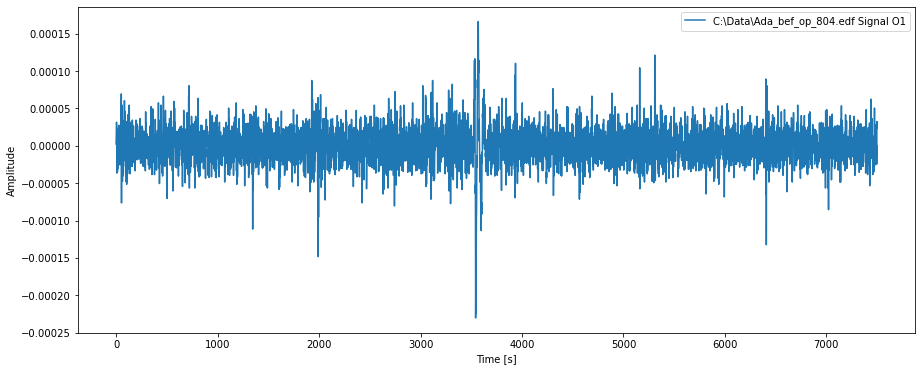

<Figure size 432x288 with 0 Axes>

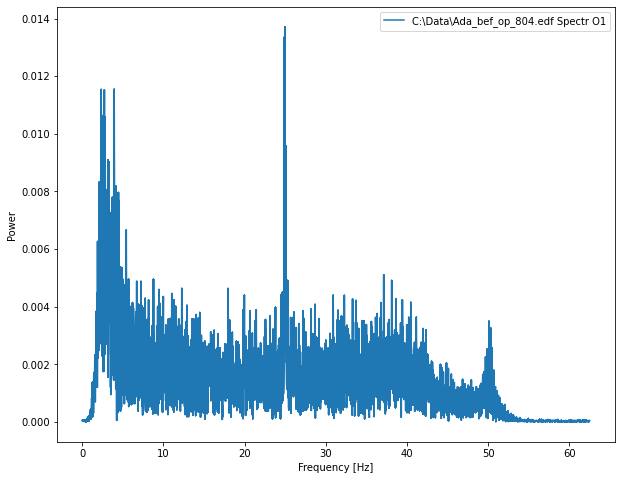

<Figure size 432x288 with 0 Axes>

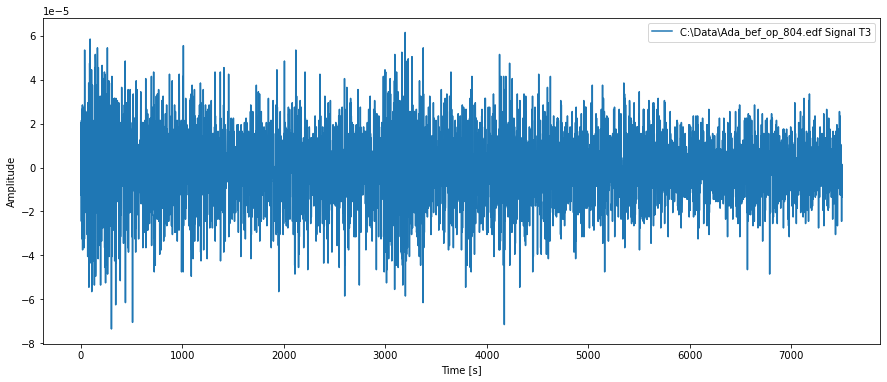

<Figure size 432x288 with 0 Axes>

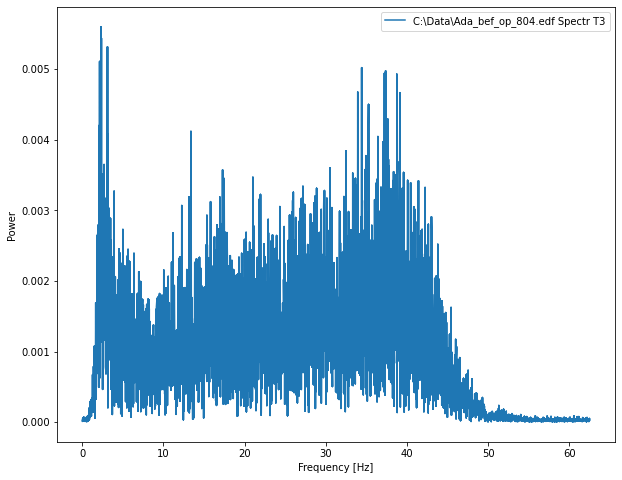

<Figure size 432x288 with 0 Axes>

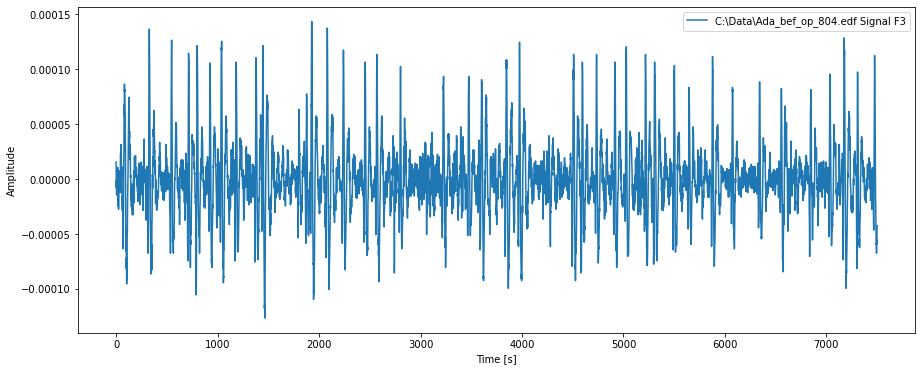

<Figure size 432x288 with 0 Axes>

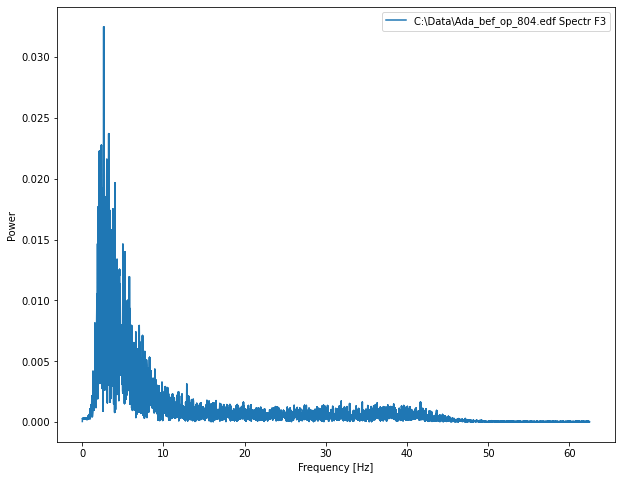

<Figure size 432x288 with 0 Axes>

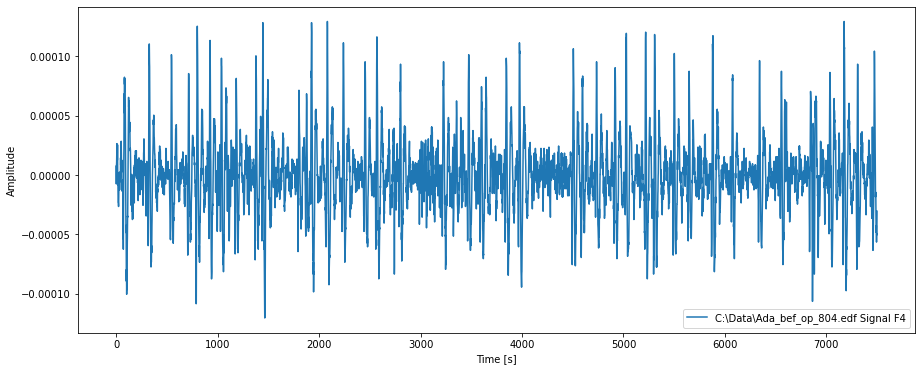

<Figure size 432x288 with 0 Axes>

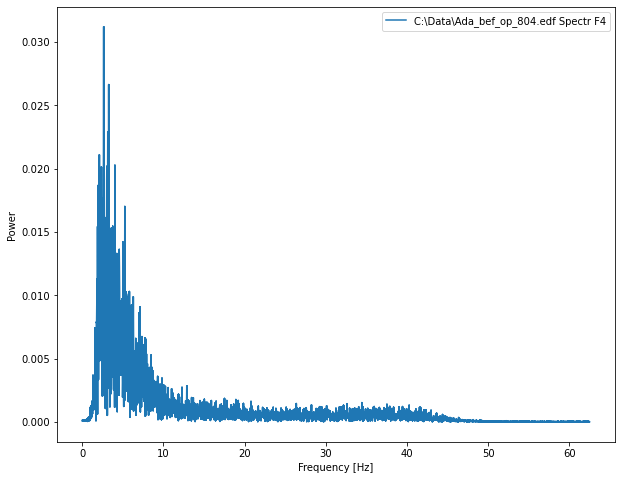

<Figure size 432x288 with 0 Axes>

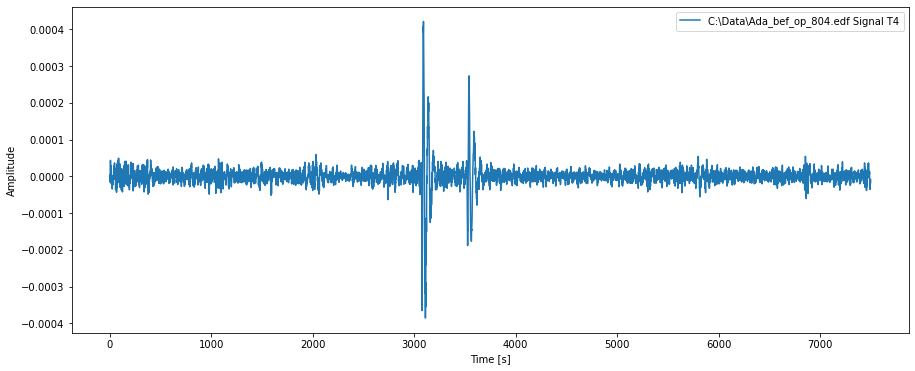

<Figure size 432x288 with 0 Axes>

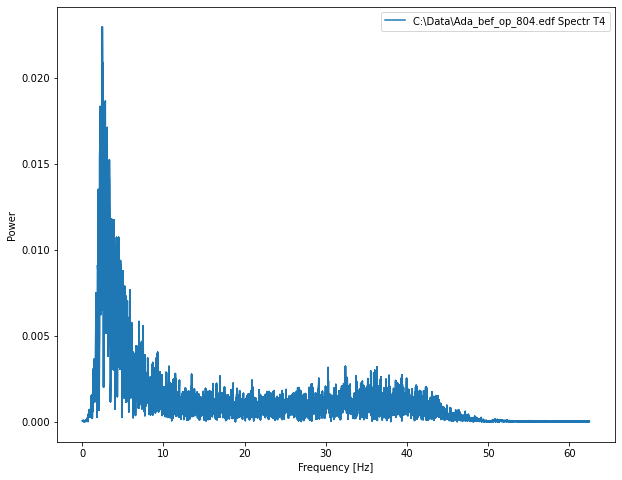

<Figure size 432x288 with 0 Axes>

In [ ]:
# Порисуем файлы, выставляем корректно lables
# ЦЕЛЬ - проверить, что надо отфильтровать, какие куски вырезать

# внимательно ставим все параметры для обработки
length_main = length1
file_with_record_main = file_with_record1
sample_rate_main = sample_rate1
edffile_main = edffile_state1

# в цикле по всем каналам
for chan in range(0,nchan-1):
    # Рисуем любой массив сигнала
    draw_signal(file_with_record_main[chan],length_main,1,edffile_main+' Signal '+raw_mne1.ch_names[chan])
    # Рисуем спектр любого массива сигнала
    draw_spectr(file_with_record_main[chan],sample_rate_main,edffile_main+' Spectr '+raw_mne1.ch_names[chan])

In [ ]:
# смотрим максимальные и средние значения амплитуд по всем каналам
for chan in range(0,nchan):
    print('Mean '+raw_mne1.ch_names[chan]+': '+str("{:.9f}".format(np.mean(abs(file_with_record_main[chan])))))
    print('Max  '+raw_mne1.ch_names[chan]+': '+str("{:.9f}".format(np.max(file_with_record_main[chan]))))
    print('Mx-Mn'+raw_mne1.ch_names[chan]+': '+str("{:.9f}".format(np.max(file_with_record_main[chan])-np.mean(abs(file_with_record_main[chan])))))

Mean O1: 0.000006969
Max  O1: 0.000033499
Mx-MnO1: 0.000026530
Mean T3: 0.000008696
Max  T3: 0.000060499
Mx-MnT3: 0.000051803
Mean F3: 0.000006501
Max  F3: 0.000079499
Mx-MnF3: 0.000072998
Mean F4: 0.000008047
Max  F4: 0.000188497
Mx-MnF4: 0.000180450
Mean T4: 0.000005951
Max  T4: 0.000035499
Mx-MnT4: 0.000029549
Mean O2: 0.000008108
Max  O2: 0.000040499
Mx-MnO2: 0.000032391


In [ ]:
# Требуется для вырезания кусочков записи определенной длины и аплитуды
# вырезаем, отрезаем очень резкие пики
# для обеих записей значения threshhold могут отличаться

# порог отсечки амплитуды, чтобы поставить корректно, смотри графики и код выше
# для 1 файла 0.0002, для второго 0.00015
threshhold = 0.0002
# количество секунд, которые вырезаются, если в куске есть превышение, рекомендуем 1
part_length_sec = 1

# сравниваем что было и что будет после очистки, если ок, дальше создаем новый файл
print('Было '+str(nchan)+' '+str(length_main))
print('Стало '+str(clearing_signal(file_with_record_main,part_length_sec,sample_rate_main,threshhold,nchan).shape))

# операцию с графиками и цифрами и очисткой надо повторить для обоих файлов
# ! рекомендуем для всех анализируемых файлов сохранить значения threshhold

Было 6 7500
Стало (6, 7125)


In [ ]:
# Создаем новый файл для работы после очистки
new_file_with_record1 = np.zeros((nchan,len(clearing_signal(file_with_record1,part_length_sec,sample_rate1,threshhold,nchan)[0])))
for chan in range(0,nchan):
    new_file_with_record1[chan] = clearing_signal(file_with_record1,part_length_sec,sample_rate1,threshhold,nchan)[chan]

# новая длина
length1 = len(new_file_with_record1[0])
print(length1)

7125


In [ ]:
# Создаем новый файл для работы после очистки
new_file_with_record2 = np.zeros((nchan,len(clearing_signal(file_with_record2,part_length_sec,sample_rate2,threshhold,nchan)[0])))
for chan in range(0,nchan):
    new_file_with_record2[chan] = clearing_signal(file_with_record2,part_length_sec,sample_rate2,threshhold,nchan)[chan]

length2 = len(new_file_with_record2[0])
print(length2)

7500


In [ ]:
# Сначала анализируем первую запись, потом вторую
# Ниже будет часть, который автоматически начнет сравнивать обе записи

In [ ]:
# внимательно ставим все параметры для обработки
length_main = len(new_file_with_record1[0])
file_with_record_main = new_file_with_record1
sample_rate_main = sample_rate1
edffile_main = edffile_state1

# Создаем сигналы по выбранным наборам частот
delta_signal = np.empty((nchan,length_main),dtype=np.object)
theta_signal = np.empty((nchan,length_main),dtype=np.object)
alpha_signal = np.empty((nchan,length_main),dtype=np.object)
beta1_signal = np.empty((nchan,length_main),dtype=np.object)
beta2_signal = np.empty((nchan,length_main),dtype=np.object)
gamma_signal = np.empty((nchan,length_main),dtype=np.object)

# Обратите внимание на значения частот в фильтре пропускания
for chan in range(0,nchan):
    delta_signal[chan] = butter_bandpass_filter(file_with_record_main[chan],bands_freq["delta_min"],bands_freq["delta_max"],sample_rate_main,4)
    theta_signal[chan] = butter_bandpass_filter(file_with_record_main[chan],bands_freq["theta_min"],bands_freq["theta_max"],sample_rate_main,5)
    alpha_signal[chan] = butter_bandpass_filter(file_with_record_main[chan],bands_freq["alpha_min"],bands_freq["alpha_max"],sample_rate_main,5)
    beta1_signal[chan] = butter_bandpass_filter(file_with_record_main[chan],bands_freq["beta1_min"],bands_freq["beta1_max"],sample_rate_main,6)
    beta2_signal[chan] = butter_bandpass_filter(file_with_record_main[chan],bands_freq["beta2_min"],bands_freq["beta2_max"],sample_rate_main,8)
    gamma_signal[chan] = butter_bandpass_filter(file_with_record_main[chan],bands_freq["gamma_min"],bands_freq["gamma_max"],sample_rate_main,9)

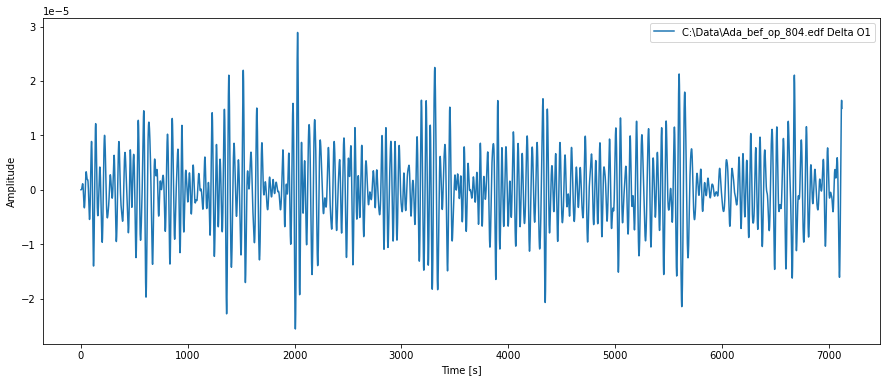

<Figure size 432x288 with 0 Axes>

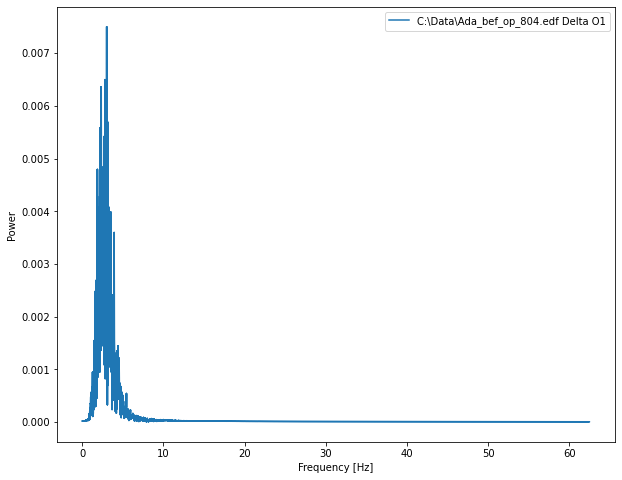

<Figure size 432x288 with 0 Axes>

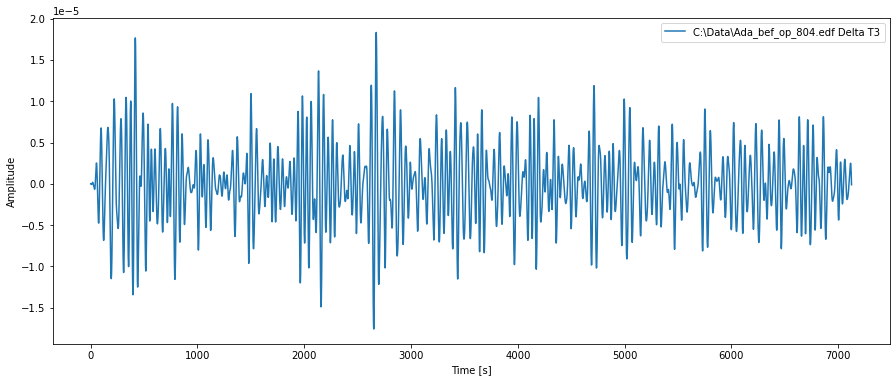

<Figure size 432x288 with 0 Axes>

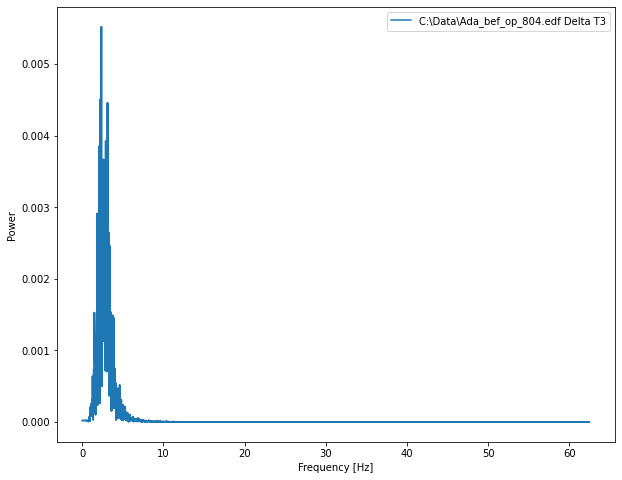

<Figure size 432x288 with 0 Axes>

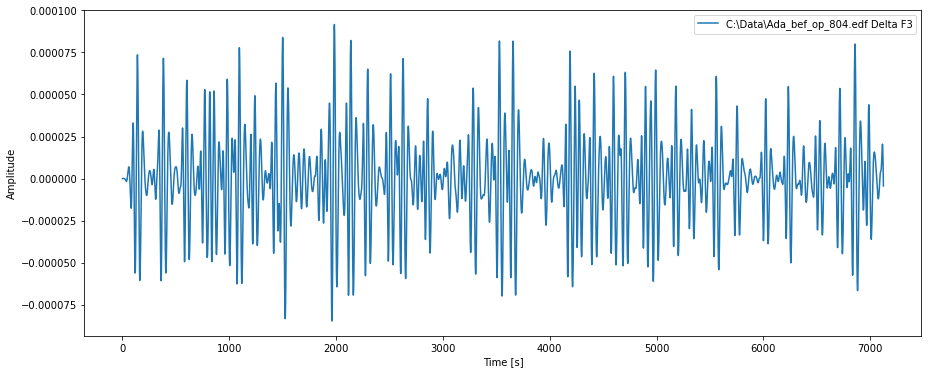

<Figure size 432x288 with 0 Axes>

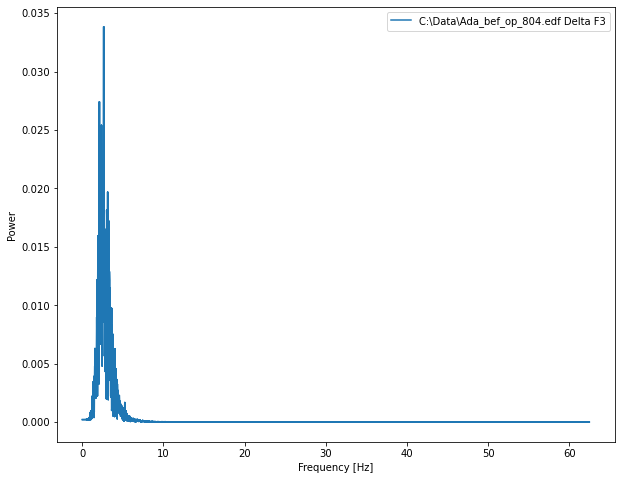

<Figure size 432x288 with 0 Axes>

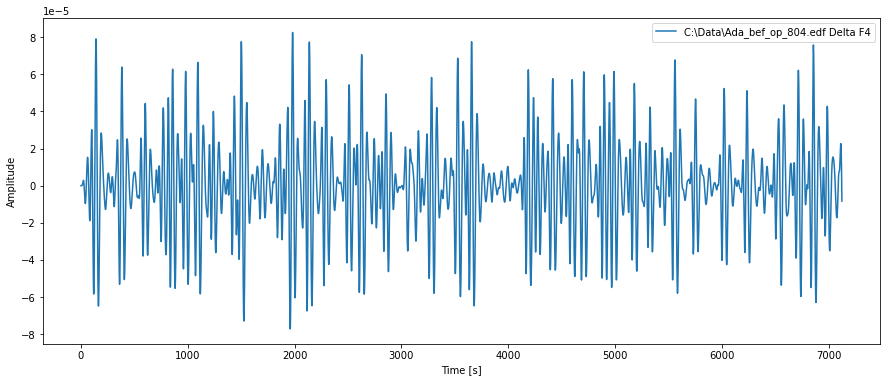

<Figure size 432x288 with 0 Axes>

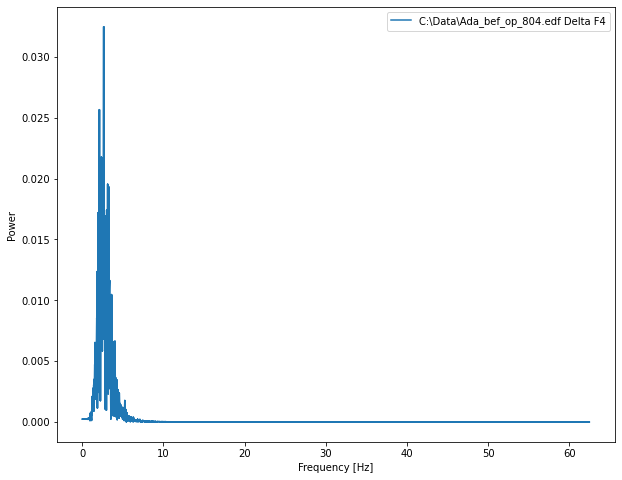

<Figure size 432x288 with 0 Axes>

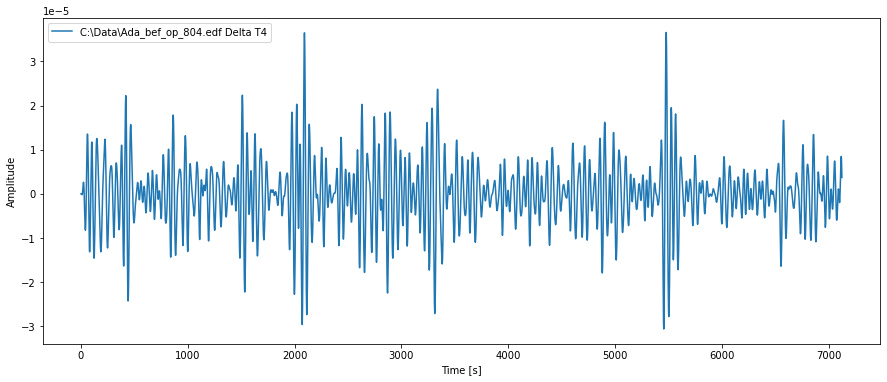

<Figure size 432x288 with 0 Axes>

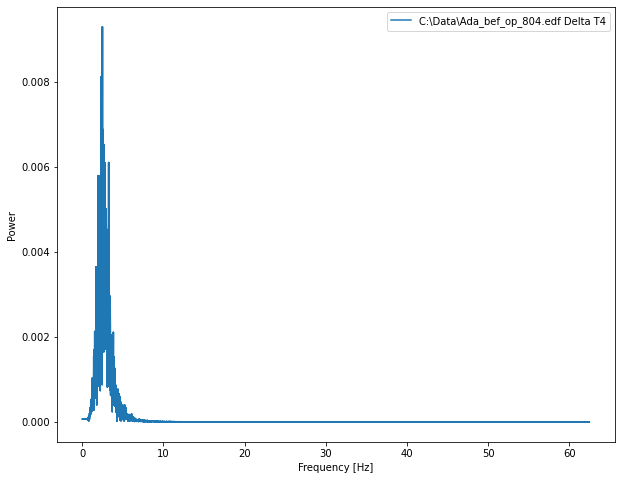

<Figure size 432x288 with 0 Axes>

In [ ]:
# Порисуем файлы, выставляем корректно lables
# Посмотрим на значения сигнала по конкретным полосам и каналам

# Рисуем любой массив сигнала
# Рисуем спектр любого массива сигнала
# в цикле по всем каналам
for chan in range(0,nchan-1):
    draw_signal(delta_signal[chan],length_main,1,edffile_main+' Delta '+raw_mne1.ch_names[chan])
    draw_spectr(delta_signal[chan],sample_rate_main,edffile_main+' Delta '+raw_mne1.ch_names[chan])

In [ ]:
# работаем с огибающей - преобразование Гильберта
hilbert_delta_signal = np.empty((nchan,length_main),dtype=np.object)
hilbert_theta_signal = np.empty((nchan,length_main),dtype=np.object)
hilbert_alpha_signal = np.empty((nchan,length_main),dtype=np.object)
hilbert_beta1_signal = np.empty((nchan,length_main),dtype=np.object)
hilbert_beta2_signal = np.empty((nchan,length_main),dtype=np.object)
hilbert_gamma_signal = np.empty((nchan,length_main),dtype=np.object)

for chan in range(0,nchan):
    hilbert_delta_signal[chan] = np.abs(hilbert(delta_signal[chan]))
    hilbert_theta_signal[chan] = np.abs(hilbert(theta_signal[chan]))
    hilbert_alpha_signal[chan] = np.abs(hilbert(alpha_signal[chan]))
    hilbert_beta1_signal[chan] = np.abs(hilbert(beta1_signal[chan]))
    hilbert_beta2_signal[chan] = np.abs(hilbert(beta2_signal[chan]))
    hilbert_gamma_signal[chan] = np.abs(hilbert(gamma_signal[chan]))
    print('Channel ' + str(chan) + ' completed')

Channel 0 completed
Channel 1 completed
Channel 2 completed
Channel 3 completed
Channel 4 completed
Channel 5 completed


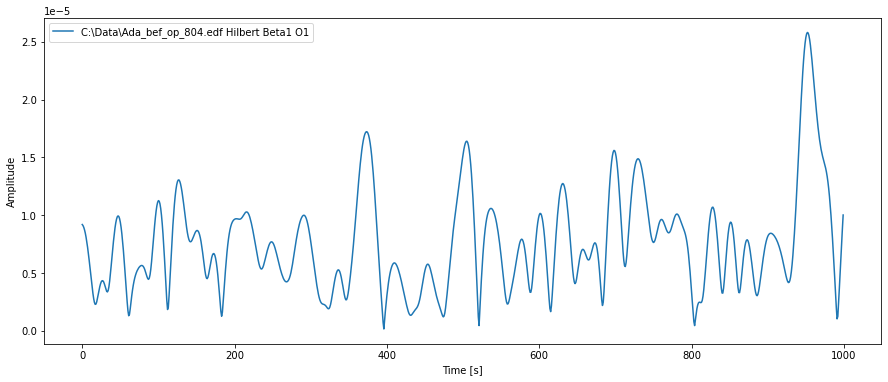

<Figure size 432x288 with 0 Axes>

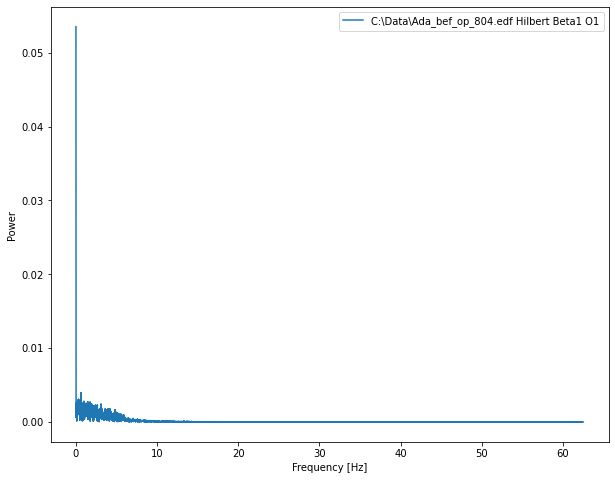

<Figure size 432x288 with 0 Axes>

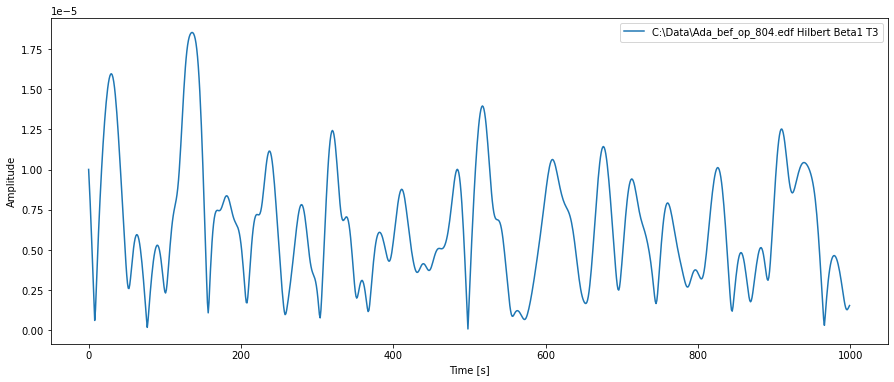

<Figure size 432x288 with 0 Axes>

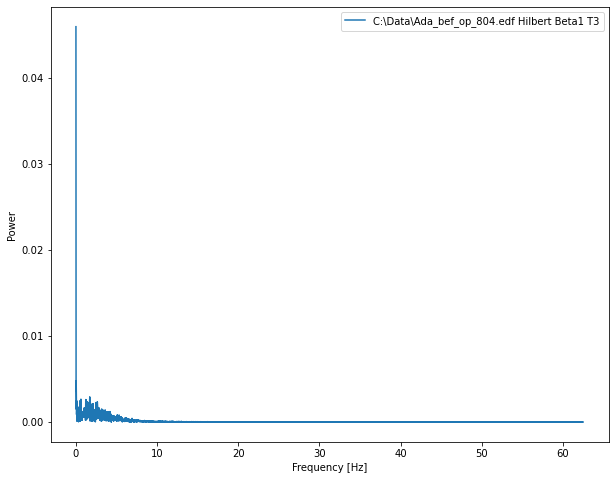

<Figure size 432x288 with 0 Axes>

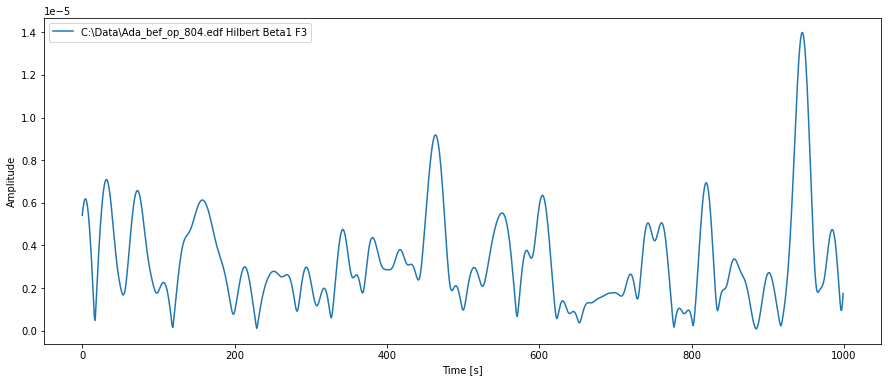

<Figure size 432x288 with 0 Axes>

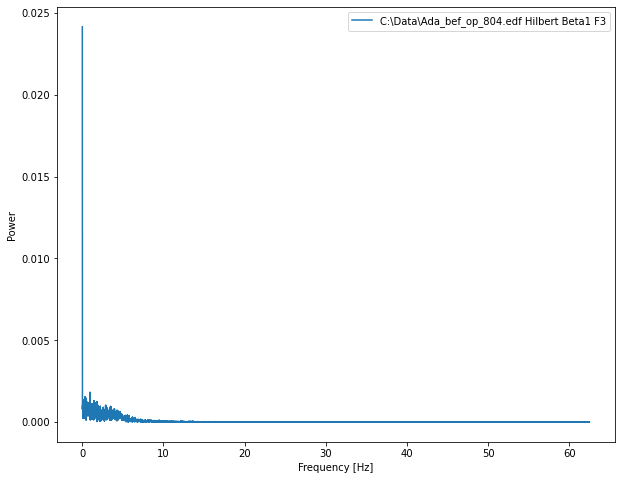

<Figure size 432x288 with 0 Axes>

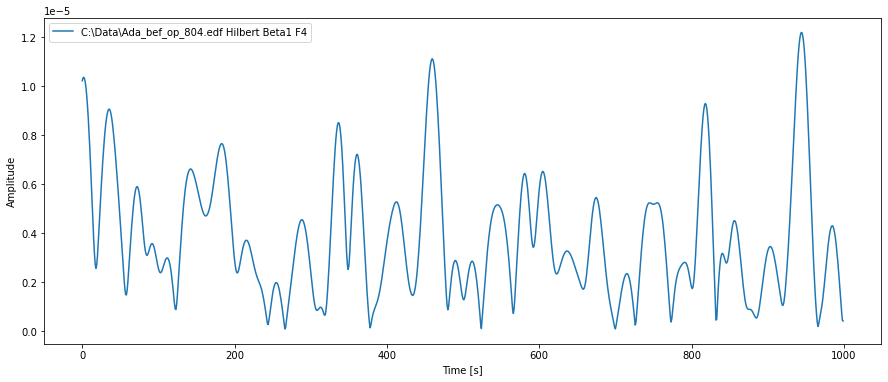

<Figure size 432x288 with 0 Axes>

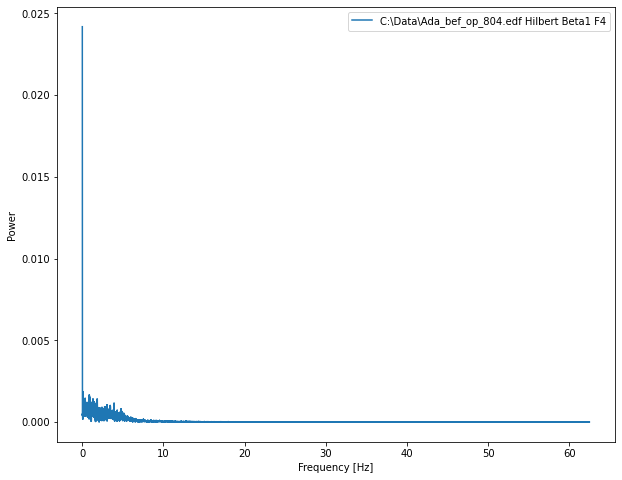

<Figure size 432x288 with 0 Axes>

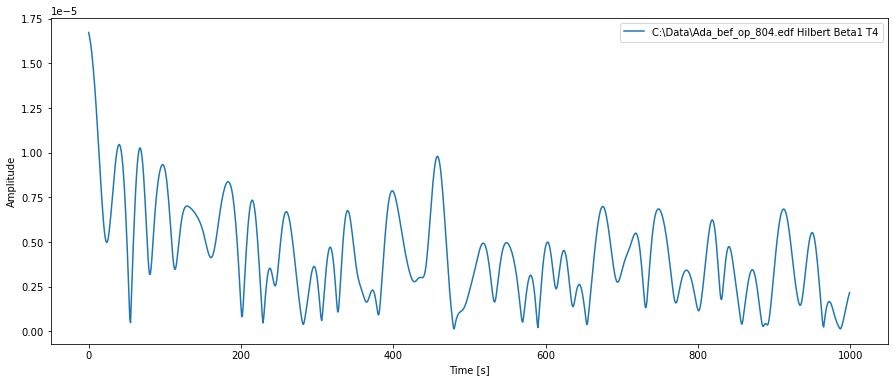

<Figure size 432x288 with 0 Axes>

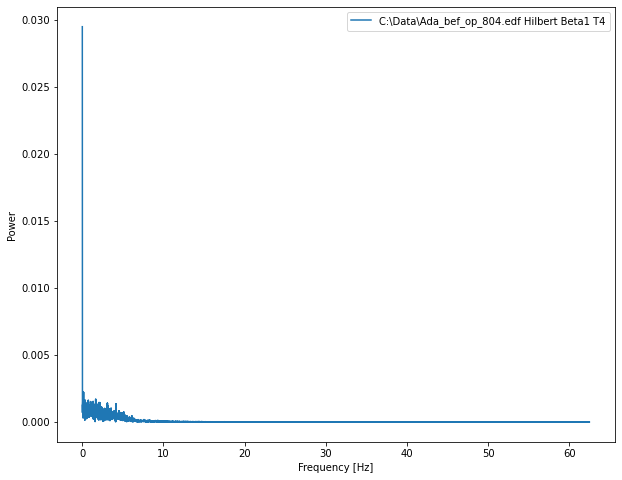

<Figure size 432x288 with 0 Axes>

In [ ]:
# Порисуем файлы, выставляем корректно lables
# Посмотрим на значения сигнала после преобразования Hilbert по конкретным полосам и каналам

# Рисуем любой массив сигнала
# Рисуем спектр любого массива сигнала
# в цикле по всем каналам
for chan in range(0,nchan-1):
    draw_signal(hilbert_beta1_signal[chan][1000:2000],1000,1,edffile_main+' Hilbert Beta1 '+raw_mne1.ch_names[chan])
    draw_spectr(hilbert_beta1_signal[chan],sample_rate_main,edffile_main+' Hilbert Beta1 '+raw_mne1.ch_names[chan])

In [ ]:
# Параметры для дальнейшего использования
downsampled_coeff = 5 # адаптируем для человеческого глаза 25 кадров в секунду 125/5

# уменьшаем размерность сигнала для рисования
downsampled_length = int(round(length_main/downsampled_coeff,0))

downsampled_hilbert_delta_signal = np.empty((nchan,downsampled_length),dtype=np.object)
downsampled_hilbert_theta_signal = np.empty((nchan,downsampled_length),dtype=np.object)
downsampled_hilbert_alpha_signal = np.empty((nchan,downsampled_length),dtype=np.object)
downsampled_hilbert_beta1_signal = np.empty((nchan,downsampled_length),dtype=np.object)
downsampled_hilbert_beta2_signal = np.empty((nchan,downsampled_length),dtype=np.object)
downsampled_hilbert_gamma_signal = np.empty((nchan,downsampled_length),dtype=np.object)

for chan in range(0,nchan):
    counter_downsampled = 0
    for i in range(0,length_main,downsampled_coeff):
        temp_sum_delta = 0
        temp_sum_theta = 0
        temp_sum_alpha = 0
        temp_sum_beta1 = 0
        temp_sum_beta2 = 0
        temp_sum_gamma = 0
        for j in range(0,downsampled_coeff,1):
            temp_sum_delta += hilbert_delta_signal[chan][i+j]
            temp_sum_theta += hilbert_theta_signal[chan][i+j]
            temp_sum_alpha += hilbert_alpha_signal[chan][i+j]
            temp_sum_beta1 += hilbert_beta1_signal[chan][i+j]
            temp_sum_beta2 += hilbert_beta2_signal[chan][i+j]
            temp_sum_gamma += hilbert_gamma_signal[chan][i+j]
        downsampled_hilbert_delta_signal[chan][counter_downsampled] = temp_sum_delta/downsampled_coeff
        downsampled_hilbert_theta_signal[chan][counter_downsampled] = temp_sum_theta/downsampled_coeff
        downsampled_hilbert_alpha_signal[chan][counter_downsampled] = temp_sum_alpha/downsampled_coeff
        downsampled_hilbert_beta1_signal[chan][counter_downsampled] = temp_sum_beta1/downsampled_coeff
        downsampled_hilbert_beta2_signal[chan][counter_downsampled] = temp_sum_beta2/downsampled_coeff
        downsampled_hilbert_gamma_signal[chan][counter_downsampled] = temp_sum_gamma/downsampled_coeff
        counter_downsampled += 1

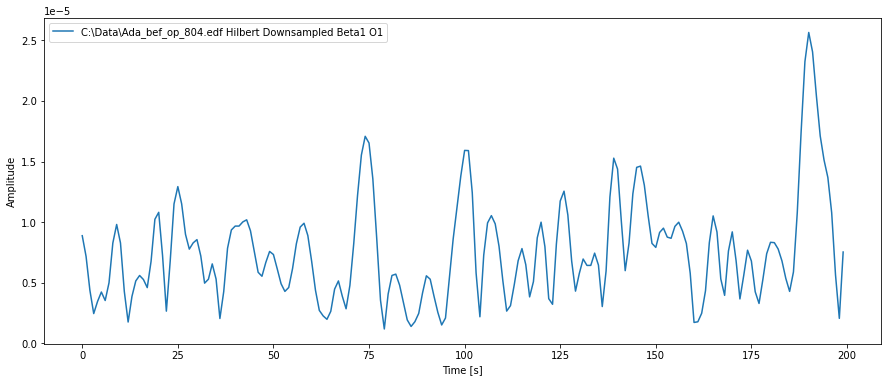

<Figure size 432x288 with 0 Axes>

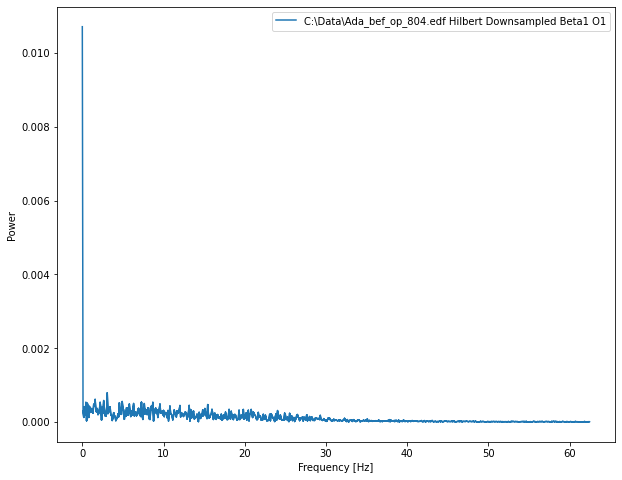

<Figure size 432x288 with 0 Axes>

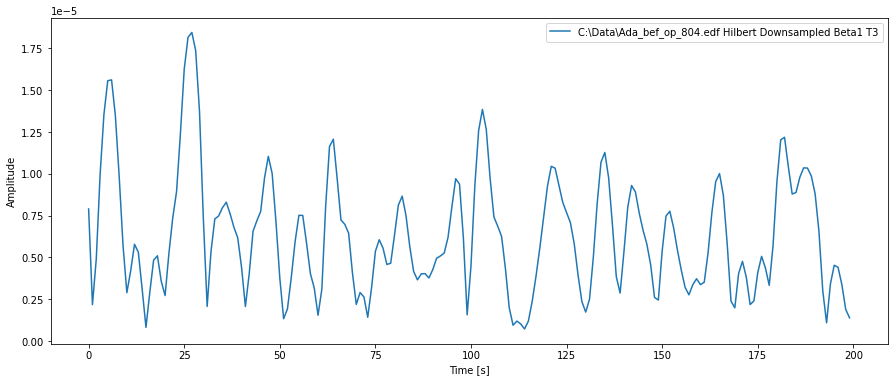

<Figure size 432x288 with 0 Axes>

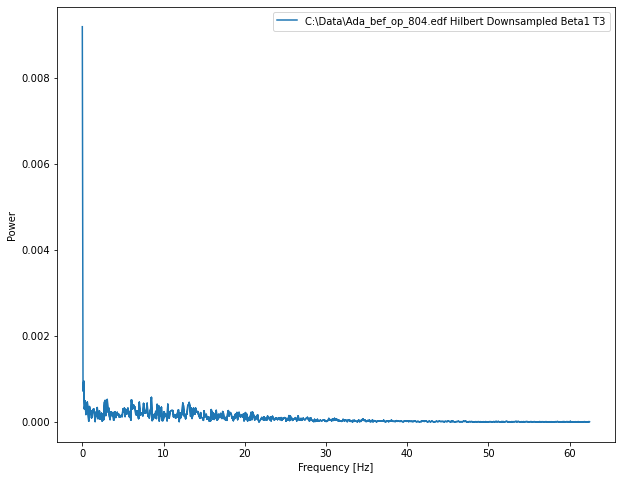

<Figure size 432x288 with 0 Axes>

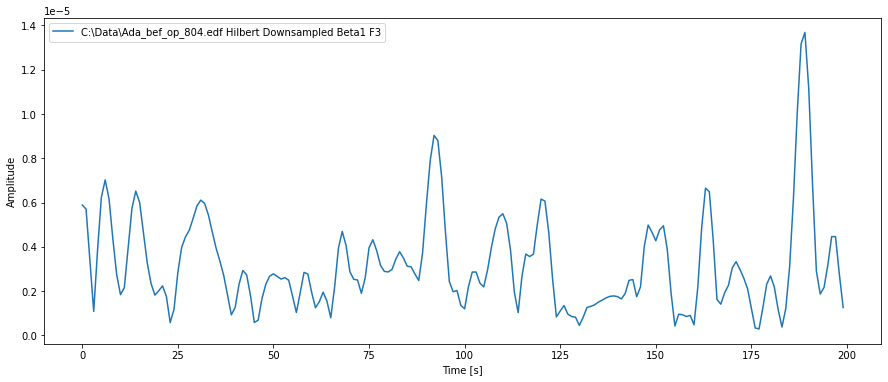

<Figure size 432x288 with 0 Axes>

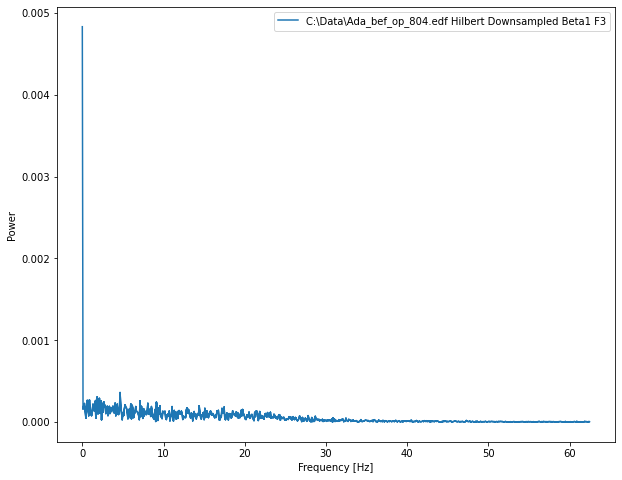

<Figure size 432x288 with 0 Axes>

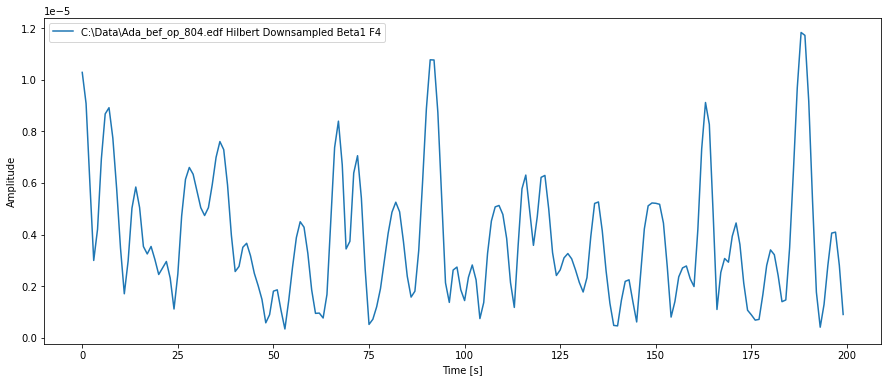

<Figure size 432x288 with 0 Axes>

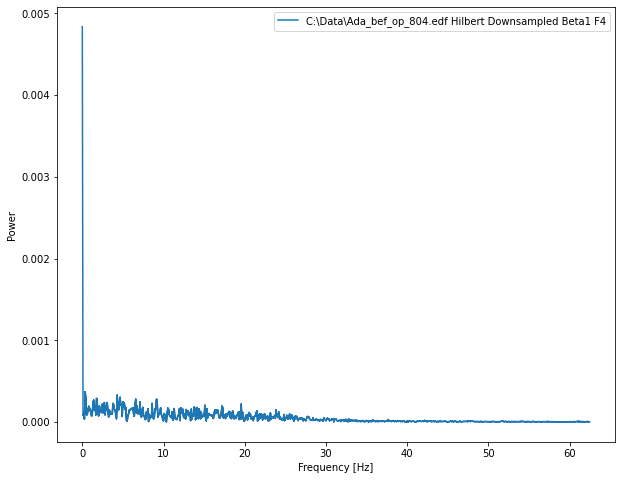

<Figure size 432x288 with 0 Axes>

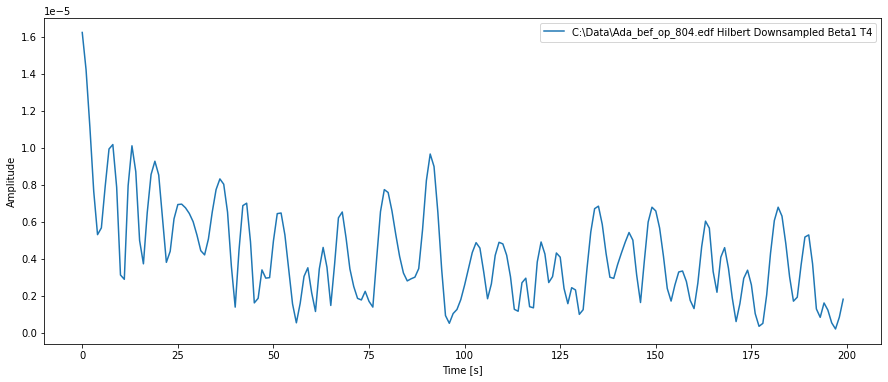

<Figure size 432x288 with 0 Axes>

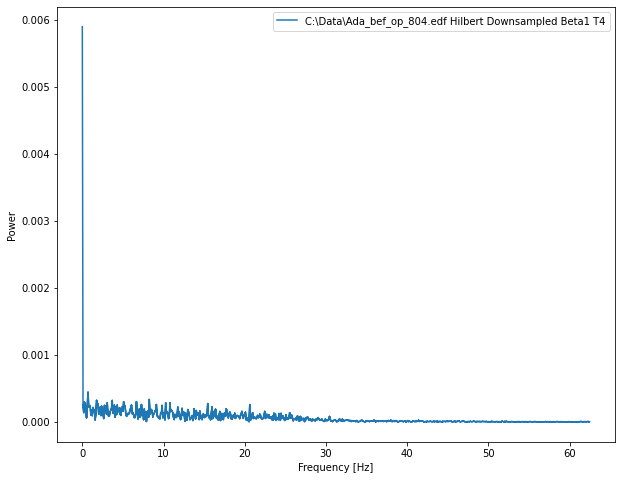

<Figure size 432x288 with 0 Axes>

In [ ]:
# Порисуем файлы, выставляем корректно lables
# Посмотрим на значения сигнала после сокращения частоты сэмплирования по конкретным полосам и каналам

# Рисуем любой массив сигнала
# Рисуем спектр любого массива сигнала
# в цикле по всем каналам
for chan in range(0,nchan-1):
    draw_signal(downsampled_hilbert_beta1_signal[chan][200:400],200,1,edffile_main+' Hilbert Downsampled Beta1 '+raw_mne1.ch_names[chan])
    draw_spectr(downsampled_hilbert_beta1_signal[chan],sample_rate_main,edffile_main+' Hilbert Downsampled Beta1 '+raw_mne1.ch_names[chan])

In [ ]:
# Блоки дальше - для рисования картинок внизу

In [ ]:
# считаем взвешенные распределения значений по частотам по обоим файлам

# ставим по максимальному порогу из двух
max_chan = 0.0002
# все значения распределяем на 100 корзин/ячеек, аля % распределения по 100% до 0.0002
number_levels = 100

all_bands_tables_percentage_state1 = np.empty((6,nchan,number_levels),dtype=np.object)
all_bands_tables_percentage_state2 = np.empty((6,nchan,number_levels),dtype=np.object)
all_bands_tables_percentage_state1 = create_percent_table(new_file_with_record1,sample_rate1,length1,downsampled_coeff,max_chan,number_levels)
all_bands_tables_percentage_state2 = create_percent_table(new_file_with_record2,sample_rate2,length2,downsampled_coeff,max_chan,number_levels)

Signal bands created
Hilbert Channel 0 completed
Hilbert Channel 1 completed
Hilbert Channel 2 completed
Hilbert Channel 3 completed
Hilbert Channel 4 completed
Hilbert Channel 5 completed
Hilbert completed
Downsampled completed
Percentage distribution completed
All bands processing completed
Signal bands created
Hilbert Channel 0 completed
Hilbert Channel 1 completed
Hilbert Channel 2 completed
Hilbert Channel 3 completed
Hilbert Channel 4 completed
Hilbert Channel 5 completed
Hilbert completed
Downsampled completed
Percentage distribution completed
All bands processing completed


In [ ]:
all_bands_tables_percentage_state1[0]

array([[6.9, 14.6, 15.9, 17.3, 15.0, 10.7, 7.4, 5.2, 2.2, 1.5, 1.7, 1.1,
        0.1, 0.2, 0.2, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,
        0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,
        0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,
        0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,
        0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,
        0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,
        0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
       [14.3, 23.7, 23.9, 19.4, 9.5, 6.5, 1.0, 1.0, 0.6, 0.3, 0.0, 0.0,
        0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,
        0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,
        0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,
        0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,
        0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0

In [ ]:
# считаем разницу между состояниями для рисования
all_bands_tables_percentage_difference_state = np.empty((6,nchan,number_levels),dtype=np.object)
all_bands_tables_percentage_difference_state = all_bands_tables_percentage_state2 - all_bands_tables_percentage_state1

In [ ]:
# Получаем из распределения по 100 ячеек - одно качественное значение для рисования
# значения амплитуды по одному каналу для одной картинки (если делать видео, то )
weightedhead_chans_delta = np.empty((nchan,1),dtype=np.object)
weightedhead_chans_theta = np.empty((nchan,1),dtype=np.object)
weightedhead_chans_alpha = np.empty((nchan,1),dtype=np.object)
weightedhead_chans_beta1 = np.empty((nchan,1),dtype=np.object)
weightedhead_chans_beta2 = np.empty((nchan,1),dtype=np.object)
weightedhead_chans_gamma = np.empty((nchan,1),dtype=np.object)

# сюда опционально заносим или % распределение по 1му состоянию, или по 2му или разницу
weightedhead_chans_delta = weightedhead_chans(all_bands_tables_percentage_state1[0],number_levels)
weightedhead_chans_theta = weightedhead_chans(all_bands_tables_percentage_state1[1],number_levels)
weightedhead_chans_alpha = weightedhead_chans(all_bands_tables_percentage_state1[2],number_levels)
weightedhead_chans_beta1 = weightedhead_chans(all_bands_tables_percentage_state1[3],number_levels)
weightedhead_chans_beta2 = weightedhead_chans(all_bands_tables_percentage_state1[4],number_levels)
weightedhead_chans_gamma = weightedhead_chans(all_bands_tables_percentage_state1[5],number_levels)

In [ ]:
print(weightedhead_chans_delta)
print(weightedhead_chans_theta)
print(weightedhead_chans_alpha)
print(weightedhead_chans_beta1)
print(weightedhead_chans_beta2)
print(weightedhead_chans_gamma)

[[4.594]
 [3.2089999999999996]
 [15.28]
 [14.758999999999999]
 [4.771]
 [3.8600000000000003]]
[[4.5]
 [2.28]
 [9.409]
 [9.296]
 [3.246]
 [3.716]]
[[5.159999999999999]
 [3.0170000000000003]
 [4.983]
 [5.156999999999998]
 [3.3909999999999996]
 [3.9210000000000003]]
[[4.269999999999999]
 [3.725]
 [2.202]
 [2.2079999999999997]
 [2.5780000000000003]
 [3.1960000000000006]]
[[6.904999999999999]
 [4.624]
 [2.1659999999999995]
 [2.0639999999999996]
 [3.0640000000000005]
 [3.7099999999999995]]
[[6.811000000000001]
 [6.512]
 [2.62]
 [2.355]
 [4.047]
 [4.812000000000001]]


In [ ]:
nchan_aug = 20

# Дополняем обычные электроды воображаемыми, для лучшей картинки
augumented_weightedhead_chans_delta = np.empty((nchan_aug,1),dtype=np.object)
augumented_weightedhead_chans_theta = np.empty((nchan_aug,1),dtype=np.object)
augumented_weightedhead_chans_alpha = np.empty((nchan_aug,1),dtype=np.object)
augumented_weightedhead_chans_beta1 = np.empty((nchan_aug,1),dtype=np.object)
augumented_weightedhead_chans_beta2 = np.empty((nchan_aug,1),dtype=np.object)
augumented_weightedhead_chans_gamma = np.empty((nchan_aug,1),dtype=np.object)

augumented_weightedhead_chans_delta = augumenting_electrodes(weightedhead_chans_delta,1)
augumented_weightedhead_chans_theta = augumenting_electrodes(weightedhead_chans_theta,1)
augumented_weightedhead_chans_alpha = augumenting_electrodes(weightedhead_chans_alpha,1)
augumented_weightedhead_chans_beta1 = augumenting_electrodes(weightedhead_chans_beta1,1)
augumented_weightedhead_chans_beta2 = augumenting_electrodes(weightedhead_chans_beta2,1)
augumented_weightedhead_chans_gamma = augumenting_electrodes(weightedhead_chans_gamma,1)

In [ ]:
# смотрим значения, чтобы прикинуть шкалы для отображения
print(augumented_weightedhead_chans_delta)
print(augumented_weightedhead_chans_theta)
print(augumented_weightedhead_chans_alpha)
print(augumented_weightedhead_chans_beta1)
print(augumented_weightedhead_chans_beta2)
print(augumented_weightedhead_chans_gamma)

[[3.9403375]
 [7.5097499999999995]
 [3.8686624999999997]
 [15.28]
 [14.758999999999999]
 [7.64]
 [7.379499999999999]
 [0.8022499999999999]
 [3.2089999999999996]
 [1.6044999999999998]
 [2.3855]
 [4.771]
 [1.19275]
 [2.297]
 [1.9300000000000002]
 [4.594]
 [3.8600000000000003]
 [1.2688375]
 [2.1135]
 [1.1439125]]
[[2.4377500000000003]
 [4.67625]
 [2.445725]
 [9.409]
 [9.296]
 [4.7045]
 [4.648]
 [0.57]
 [2.28]
 [1.14]
 [1.623]
 [3.246]
 [0.8115]
 [2.25]
 [1.858]
 [4.5]
 [3.716]
 [1.2105]
 [2.0540000000000003]
 [1.0507250000000001]]
[[1.3588874999999998]
 [2.5349999999999993]
 [1.4164124999999996]
 [4.983]
 [5.156999999999998]
 [2.4915]
 [2.578499999999999]
 [0.7542500000000001]
 [3.0170000000000003]
 [1.5085000000000002]
 [1.6954999999999998]
 [3.3909999999999996]
 [0.8477499999999999]
 [2.5799999999999996]
 [1.9605000000000001]
 [5.159999999999999]
 [3.9210000000000003]
 [1.4031374999999997]
 [2.27025]
 [1.1074125000000001]]
[[0.6901875]
 [1.1025]
 [0.6486749999999999]
 [2.202]
 [2.207999

In [ ]:
# Задаем шкалы для рисования
min_main = -1
max_main = 10
step_main = 0.1

max_delta = max_main
step_delta = step_main
max_theta = max_main
step_theta = step_main
max_alpha = max_main
step_alpha = step_main
max_beta1 = max_main
step_beta1 = step_main
max_beta2 = max_main
step_beta2 = step_main
max_gamma = max_main
step_gamma = step_main

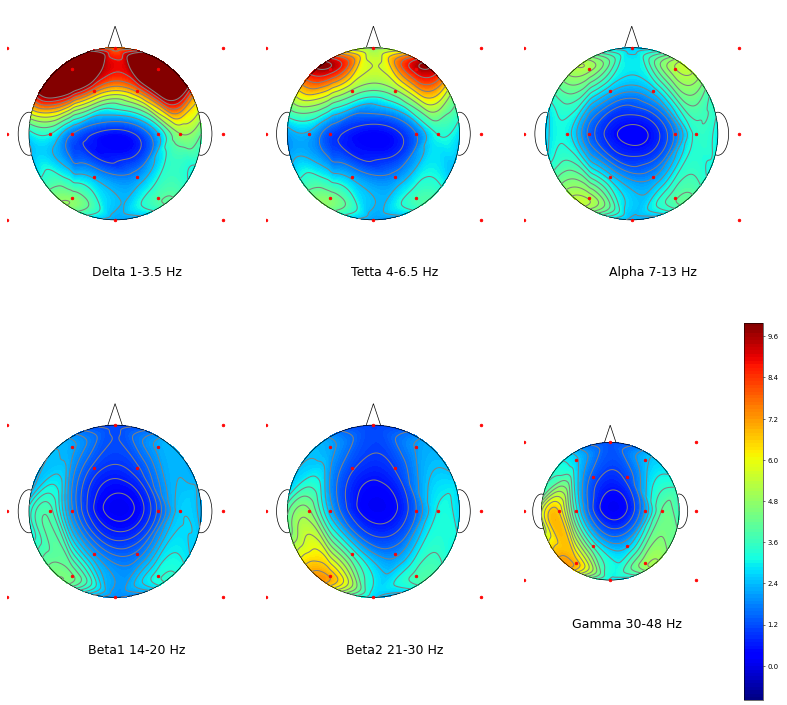

<Figure size 432x288 with 0 Axes>

In [ ]:
# Рисуем одну картинку
# Дополненные координаты с воображаемыми электродами для хорошего рисования
koord_aug = [[0,5],[2.5,5],[5,5],
             [1.5,4.5],[3.5,4.5],
             [2,4],[3,4],
             [0,3],[1,3],[1.5,3],[3.5,3],[4,3],[5,3],
             [2,2],[3,2],
             [1.5,1.5],[3.5,1.5],
             [0,1],[2.5,1],[5,1]]

end_point = 1
counter = 0
time_points = np.arange(counter,end_point,1)

fig = plt.figure(figsize=(20,20), dpi = 50)
gs = gridspec.GridSpec(2, 3)

for time_point in time_points:
    x_counter = 0
    y_counter = 0
    for one_time in range(0,6):
        # Берем набор значений сигнала для рисования
        point_amplitude = []
        if (x_counter==0 and y_counter==0):
            for chan in range(nchan_aug):
                point_amplitude.append(augumented_weightedhead_chans_delta[chan][time_point])
                level_points = np.arange(min_main,max_delta+step_delta,step_delta)
        if (x_counter==0 and y_counter==1):
            for chan in range(nchan_aug):
                point_amplitude.append(augumented_weightedhead_chans_theta[chan][time_point])
                level_points = np.arange(min_main,max_theta+step_theta,step_theta)
        if (x_counter==0 and y_counter==2):
            for chan in range(nchan_aug):
                point_amplitude.append(augumented_weightedhead_chans_alpha[chan][time_point])
                level_points = np.arange(min_main,max_alpha+step_alpha,step_alpha)
        if (x_counter==1 and y_counter==0):
            for chan in range(nchan_aug):
                point_amplitude.append(augumented_weightedhead_chans_beta1[chan][time_point])
                level_points = np.arange(min_main,max_beta1+step_beta1,step_beta1)
        if (x_counter==1 and y_counter==1):
            for chan in range(nchan_aug):
                point_amplitude.append(augumented_weightedhead_chans_beta2[chan][time_point])
                level_points = np.arange(min_main,max_beta2+step_beta2,step_beta2)
        if (x_counter==1 and y_counter==2):
            for chan in range(nchan_aug):
                point_amplitude.append(augumented_weightedhead_chans_gamma[chan][time_point])
                level_points = np.arange(min_main,max_gamma+step_gamma,step_gamma)

        N = 200             # number of points for interpolation
        xy_center = [2.5,3]   # center of the plot
        radius = 2          # radius

        x,y = [],[]
        for i in koord_aug:
            x.append(i[0])
            y.append(i[1])
        z = point_amplitude
        xi = np.linspace(0, 5, N)
        yi = np.linspace(0, 5, N)
        zi = scipy.interpolate.griddata((x, y), z, (xi[None,:], yi[:,None]), method='cubic')
        for i in range(N):
            for j in range(N):
                #if zi[j,i] < 0:
                #    zi[j,i] = 0
                if (x_counter==0 and y_counter==0) and zi[j,i] > max_delta:
                    zi[j,i] = max_delta-0.1
                if (x_counter==0 and y_counter==1) and zi[j,i] > max_theta:
                    zi[j,i] = max_theta
                if (x_counter==0 and y_counter==2) and zi[j,i] > max_alpha:
                    zi[j,i] = max_alpha
                if (x_counter==1 and y_counter==0) and zi[j,i] > max_beta1:
                    zi[j,i] = max_beta1
                if (x_counter==1 and y_counter==1) and zi[j,i] > max_beta2:
                    zi[j,i] = max_beta2
                if (x_counter==1 and y_counter==2) and zi[j,i] > max_gamma:
                    zi[j,i] = max_gamma
        # set points > radius to not-a-number. They will not be plotted.
        # the dr/2 makes the edges a bit smoother
        dr = xi[1] - xi[0]
        for i in range(N):
            for j in range(N):
                r = np.sqrt((xi[i] - xy_center[0])**2 + (yi[j] - xy_center[1])**2)
                if (r - dr/2) > radius:
                    zi[j,i] = "nan"

        # set aspect = 1 to make it a circle
        ax = plt.subplot(gs[x_counter,y_counter], aspect = 1)
        if (x_counter==0 and y_counter==0):
            plt.xlabel('Delta '+str(bands_freq["delta_min"])+'-'+str(bands_freq["delta_max"])+' Hz', fontsize=18)
        if (x_counter==0 and y_counter==1):
            plt.xlabel('Tetta '+str(bands_freq["theta_min"])+'-'+str(bands_freq["theta_max"])+' Hz', fontsize=18)
        if (x_counter==0 and y_counter==2):
            plt.xlabel('Alpha '+str(bands_freq["alpha_min"])+'-'+str(bands_freq["alpha_max"])+' Hz', fontsize=18)
        if (x_counter==1 and y_counter==0):
            plt.xlabel('Beta1 '+str(bands_freq["beta1_min"])+'-'+str(bands_freq["beta1_max"])+' Hz', fontsize=18)
        if (x_counter==1 and y_counter==1):
            plt.xlabel('Beta2 '+str(bands_freq["beta2_min"])+'-'+str(bands_freq["beta2_max"])+' Hz', fontsize=18)
        if (x_counter==1 and y_counter==2):
            plt.xlabel('Gamma '+str(bands_freq["gamma_min"])+'-'+str(bands_freq["gamma_max"])+' Hz', fontsize=18)

        y_counter += 1
        if (y_counter == 3 and x_counter == 0):
            x_counter = 1
            y_counter = 0

        # use different number of levels for the fill and the lines
        CS = ax.contourf(xi, yi, zi, level_points, cmap = plt.cm.jet, zorder = 1)
        ax.contour(xi, yi, zi, 15, colors = "grey", zorder = 2)

        # add the data points
        # I guess there are no data points outside the head...
        ax.scatter(x, y, marker = 'o', c = 'r', s = 15, zorder = 3)
        # draw a circle
        circle = matplotlib.patches.Circle(xy = xy_center, radius = radius, edgecolor = "k", facecolor = "none")
        ax.add_patch(circle)
        # make the axis invisible
        for loc, spine in ax.spines.items():
            spine.set_linewidth(0)
        # remove the ticks
        ax.set_xticks([])
        ax.set_yticks([])
        # Add some body parts. Hide unwanted parts by setting the zorder low
        # add two ears
        circle = matplotlib.patches.Ellipse(xy = [0.5,3], width = 0.5, height = 1.0, angle = 0, edgecolor = "k", facecolor = "w", zorder = 0)
        ax.add_patch(circle)
        circle = matplotlib.patches.Ellipse(xy = [4.5,3], width = 0.5, height = 1.0, angle = 0, edgecolor = "k", facecolor = "w", zorder = 0)
        ax.add_patch(circle)
        # add a nose
        xy = [[2,4], [2.5,5.5],[3,4]]
        polygon = matplotlib.patches.Polygon(xy = xy, edgecolor = "k", facecolor = "w", zorder = 0)
        ax.add_patch(polygon)
        # set axes limits
        ax.set_xlim(0, 6)
        ax.set_ylim(0, 6)
    fig.subplots_adjust(wspace=0, hspace=0)
    plt.savefig('C:\\Data\\Ada\\' + str(counter).zfill(6) + '_fig.jpeg')

    # make a color bar
    #cbar = fig.colorbar(CS, ax=ax)

    plt.show()
    counter += 1
    plt.clf()
    gc.collect()

In [ ]:
# Повторяем ряд шагов для рисования набора картинок - т.к. идет рисование не по усредненным, а по предобработанным

In [ ]:
# внимательно ставим все параметры для обработки
length_main = len(new_file_with_record1[0])
file_with_record_main = new_file_with_record1
sample_rate_main = sample_rate1
edffile_main = edffile_state1


# Создаем сигналы по выбранным наборам частот
delta_signal = np.empty((nchan,length_main),dtype=np.object)
theta_signal = np.empty((nchan,length_main),dtype=np.object)
alpha_signal = np.empty((nchan,length_main),dtype=np.object)
beta1_signal = np.empty((nchan,length_main),dtype=np.object)
beta2_signal = np.empty((nchan,length_main),dtype=np.object)
gamma_signal = np.empty((nchan,length_main),dtype=np.object)

# Обратите внимание на значения частот в фильтре пропускания
for chan in range(0,nchan):
    delta_signal[chan] = butter_bandpass_filter(file_with_record_main[chan],bands_freq["delta_min"],bands_freq["delta_max"],sample_rate_main,4)
    theta_signal[chan] = butter_bandpass_filter(file_with_record_main[chan],bands_freq["theta_min"],bands_freq["theta_max"],sample_rate_main,5)
    alpha_signal[chan] = butter_bandpass_filter(file_with_record_main[chan],bands_freq["alpha_min"],bands_freq["alpha_max"],sample_rate_main,5)
    beta1_signal[chan] = butter_bandpass_filter(file_with_record_main[chan],bands_freq["beta1_min"],bands_freq["beta1_max"],sample_rate_main,6)
    beta2_signal[chan] = butter_bandpass_filter(file_with_record_main[chan],bands_freq["beta2_min"],bands_freq["beta2_max"],sample_rate_main,8)
    gamma_signal[chan] = butter_bandpass_filter(file_with_record_main[chan],bands_freq["gamma_min"],bands_freq["gamma_max"],sample_rate_main,9)

In [ ]:
# работаем с огибающей - преобразование Гильберта
hilbert_delta_signal = np.empty((nchan,length_main),dtype=np.object)
hilbert_theta_signal = np.empty((nchan,length_main),dtype=np.object)
hilbert_alpha_signal = np.empty((nchan,length_main),dtype=np.object)
hilbert_beta1_signal = np.empty((nchan,length_main),dtype=np.object)
hilbert_beta2_signal = np.empty((nchan,length_main),dtype=np.object)
hilbert_gamma_signal = np.empty((nchan,length_main),dtype=np.object)

for chan in range(0,nchan):
    hilbert_delta_signal[chan] = np.abs(hilbert(delta_signal[chan]))
    hilbert_theta_signal[chan] = np.abs(hilbert(theta_signal[chan]))
    hilbert_alpha_signal[chan] = np.abs(hilbert(alpha_signal[chan]))
    hilbert_beta1_signal[chan] = np.abs(hilbert(beta1_signal[chan]))
    hilbert_beta2_signal[chan] = np.abs(hilbert(beta2_signal[chan]))
    hilbert_gamma_signal[chan] = np.abs(hilbert(gamma_signal[chan]))
    print('Channel ' + str(chan) + ' completed')

Channel 0 completed
Channel 1 completed
Channel 2 completed
Channel 3 completed
Channel 4 completed
Channel 5 completed


In [ ]:
# Параметры для дальнейшего использования
downsampled_coeff = 5 # адаптируем для человеческого глаза 25 кадров в секунду 125/5

# уменьшаем размерность сигнала для рисования
downsampled_length = int(round(length_main/downsampled_coeff,0))

downsampled_hilbert_delta_signal = np.empty((nchan,downsampled_length),dtype=np.object)
downsampled_hilbert_theta_signal = np.empty((nchan,downsampled_length),dtype=np.object)
downsampled_hilbert_alpha_signal = np.empty((nchan,downsampled_length),dtype=np.object)
downsampled_hilbert_beta1_signal = np.empty((nchan,downsampled_length),dtype=np.object)
downsampled_hilbert_beta2_signal = np.empty((nchan,downsampled_length),dtype=np.object)
downsampled_hilbert_gamma_signal = np.empty((nchan,downsampled_length),dtype=np.object)

for chan in range(0,nchan):
    counter_downsampled = 0
    for i in range(0,length_main,downsampled_coeff):
        temp_sum_delta = 0
        temp_sum_theta = 0
        temp_sum_alpha = 0
        temp_sum_beta1 = 0
        temp_sum_beta2 = 0
        temp_sum_gamma = 0
        for j in range(0,downsampled_coeff,1):
            temp_sum_delta += hilbert_delta_signal[chan][i+j]
            temp_sum_theta += hilbert_theta_signal[chan][i+j]
            temp_sum_alpha += hilbert_alpha_signal[chan][i+j]
            temp_sum_beta1 += hilbert_beta1_signal[chan][i+j]
            temp_sum_beta2 += hilbert_beta2_signal[chan][i+j]
            temp_sum_gamma += hilbert_gamma_signal[chan][i+j]
        downsampled_hilbert_delta_signal[chan][counter_downsampled] = temp_sum_delta/downsampled_coeff
        downsampled_hilbert_theta_signal[chan][counter_downsampled] = temp_sum_theta/downsampled_coeff
        downsampled_hilbert_alpha_signal[chan][counter_downsampled] = temp_sum_alpha/downsampled_coeff
        downsampled_hilbert_beta1_signal[chan][counter_downsampled] = temp_sum_beta1/downsampled_coeff
        downsampled_hilbert_beta2_signal[chan][counter_downsampled] = temp_sum_beta2/downsampled_coeff
        downsampled_hilbert_gamma_signal[chan][counter_downsampled] = temp_sum_gamma/downsampled_coeff
        counter_downsampled += 1

In [ ]:
nchan_aug = 20

# Дополняем обычные электроды воображаемыми, для лучшей картинки
augumented_downsampled_hilbert_delta_signal = np.empty((nchan_aug,downsampled_length),dtype=np.object)
augumented_downsampled_hilbert_theta_signal = np.empty((nchan_aug,downsampled_length),dtype=np.object)
augumented_downsampled_hilbert_alpha_signal = np.empty((nchan_aug,downsampled_length),dtype=np.object)
augumented_downsampled_hilbert_beta1_signal = np.empty((nchan_aug,downsampled_length),dtype=np.object)
augumented_downsampled_hilbert_beta2_signal = np.empty((nchan_aug,downsampled_length),dtype=np.object)
augumented_downsampled_hilbert_gamma_signal = np.empty((nchan_aug,downsampled_length),dtype=np.object)

augumented_downsampled_hilbert_delta_signal = augumenting_electrodes(downsampled_hilbert_delta_signal,downsampled_length)
augumented_downsampled_hilbert_theta_signal = augumenting_electrodes(downsampled_hilbert_theta_signal,downsampled_length)
augumented_downsampled_hilbert_alpha_signal = augumenting_electrodes(downsampled_hilbert_alpha_signal,downsampled_length)
augumented_downsampled_hilbert_beta1_signal = augumenting_electrodes(downsampled_hilbert_beta1_signal,downsampled_length)
augumented_downsampled_hilbert_beta2_signal = augumenting_electrodes(downsampled_hilbert_beta2_signal,downsampled_length)
augumented_downsampled_hilbert_gamma_signal = augumenting_electrodes(downsampled_hilbert_gamma_signal,downsampled_length)

In [ ]:
# смотрим максимальные и минимальные значения амплитуд по всем записям и каналам, чтобы подобрать корректные шкалы
# !!! тут нужны другие значения, т.к. мы работаем не с усредненными и взвешенными, а с оригинальными значениями
for chan in range(0,nchan):
    print('Delta Min  '+raw_mne1.ch_names[chan]+': '+str("{:.9f}".format(np.min(augumented_downsampled_hilbert_delta_signal[chan]))))
    print('Delta Max  '+raw_mne1.ch_names[chan]+': '+str("{:.9f}".format(np.max(augumented_downsampled_hilbert_delta_signal[chan]))))

for chan in range(0,nchan):
    print('Theta Min  '+raw_mne1.ch_names[chan]+': '+str("{:.9f}".format(np.min(downsampled_hilbert_theta_signal[chan]))))
    print('Theta Max  '+raw_mne1.ch_names[chan]+': '+str("{:.9f}".format(np.max(downsampled_hilbert_theta_signal[chan]))))

for chan in range(0,nchan):
    print('Alpha Min  '+raw_mne1.ch_names[chan]+': '+str("{:.9f}".format(np.min(downsampled_hilbert_alpha_signal[chan]))))
    print('Alpha Max  '+raw_mne1.ch_names[chan]+': '+str("{:.9f}".format(np.max(downsampled_hilbert_alpha_signal[chan]))))

for chan in range(0,nchan):
    print('Beta1 Min  '+raw_mne1.ch_names[chan]+': '+str("{:.9f}".format(np.min(downsampled_hilbert_beta1_signal[chan]))))
    print('Beta1 Max  '+raw_mne1.ch_names[chan]+': '+str("{:.9f}".format(np.max(downsampled_hilbert_beta1_signal[chan]))))

for chan in range(0,nchan):
    print('Beta2 Min  '+raw_mne1.ch_names[chan]+': '+str("{:.9f}".format(np.min(downsampled_hilbert_beta2_signal[chan]))))
    print('Beta2 Max  '+raw_mne1.ch_names[chan]+': '+str("{:.9f}".format(np.max(downsampled_hilbert_beta2_signal[chan]))))

for chan in range(0,nchan):
    print('Gamma Min  '+raw_mne1.ch_names[chan]+': '+str("{:.9f}".format(np.min(downsampled_hilbert_gamma_signal[chan]))))
    print('Gamma Max  '+raw_mne1.ch_names[chan]+': '+str("{:.9f}".format(np.max(downsampled_hilbert_gamma_signal[chan]))))

Delta Min  O1: 0.000000329
Delta Max  O1: 0.000023886
Delta Min  T3: 0.000000569
Delta Max  T3: 0.000044461
Delta Min  F3: 0.000000217
Delta Max  F3: 0.000021752
Delta Min  F4: 0.000000670
Delta Max  F4: 0.000093790
Delta Min  T4: 0.000000609
Delta Max  T4: 0.000084340
Delta Min  O2: 0.000000335
Delta Max  O2: 0.000046895
Theta Min  O1: 0.000000329
Theta Max  O1: 0.000021292
Theta Min  T3: 0.000000062
Theta Max  T3: 0.000012238
Theta Min  F3: 0.000000149
Theta Max  F3: 0.000061098
Theta Min  F4: 0.000000391
Theta Max  F4: 0.000059939
Theta Min  T4: 0.000000133
Theta Max  T4: 0.000023397
Theta Min  O2: 0.000000298
Theta Max  O2: 0.000017845
Alpha Min  O1: 0.000000472
Alpha Max  O1: 0.000030455
Alpha Min  T3: 0.000000167
Alpha Max  T3: 0.000015116
Alpha Min  F3: 0.000000415
Alpha Max  F3: 0.000042443
Alpha Min  F4: 0.000000363
Alpha Max  F4: 0.000041373
Alpha Min  T4: 0.000000326
Alpha Max  T4: 0.000043475
Alpha Min  O2: 0.000000339
Alpha Max  O2: 0.000023932
Beta1 Min  O1: 0.000000357
B

In [ ]:
# Задаем шкалы для рисования
min_main = 0
max_main = 0.0001
step_main = 0.00001

max_delta = max_main
step_delta = step_main
max_theta = max_main
step_theta = step_main
max_alpha = max_main
step_alpha = step_main
max_beta1 = max_main
step_beta1 = step_main
max_beta2 = max_main
step_beta2 = step_main
max_gamma = max_main
step_gamma = step_main

In [ ]:
# Рисуем все картинки по записи для создания видео
# Дополненные координаты с воображаемыми электродами для хорошего рисования
koord_aug = [[0,5],[2.5,5],[5,5],
             [1.5,4.5],[3.5,4.5],
             [2,4],[3,4],
             [0,3],[1,3],[1.5,3],[3.5,3],[4,3],[5,3],
             [2,2],[3,2],
             [1.5,1.5],[3.5,1.5],
             [0,1],[2.5,1],[5,1]]

end_point = downsampled_length
counter = 0
time_points = np.arange(counter,end_point,1)

fig = plt.figure(figsize=(20,20), dpi = 50)
gs = gridspec.GridSpec(2, 3)

for time_point in time_points:
    x_counter = 0
    y_counter = 0
    for one_time in range(0,6):
        # Берем набор значений сигнала для рисования
        point_amplitude = []
        if (x_counter==0 and y_counter==0):
            for chan in range(nchan_aug):
                point_amplitude.append(augumented_downsampled_hilbert_delta_signal[chan][time_point])
                level_points = np.arange(min_main,max_delta+step_delta,step_delta)
        if (x_counter==0 and y_counter==1):
            for chan in range(nchan_aug):
                point_amplitude.append(augumented_downsampled_hilbert_theta_signal[chan][time_point])
                level_points = np.arange(min_main,max_theta+step_theta,step_theta)
        if (x_counter==0 and y_counter==2):
            for chan in range(nchan_aug):
                point_amplitude.append(augumented_downsampled_hilbert_alpha_signal[chan][time_point])
                level_points = np.arange(min_main,max_alpha+step_alpha,step_alpha)
        if (x_counter==1 and y_counter==0):
            for chan in range(nchan_aug):
                point_amplitude.append(augumented_downsampled_hilbert_beta1_signal[chan][time_point])
                level_points = np.arange(min_main,max_beta1+step_beta1,step_beta1)
        if (x_counter==1 and y_counter==1):
            for chan in range(nchan_aug):
                point_amplitude.append(augumented_downsampled_hilbert_beta2_signal[chan][time_point])
                level_points = np.arange(min_main,max_beta2+step_beta2,step_beta2)
        if (x_counter==1 and y_counter==2):
            for chan in range(nchan_aug):
                point_amplitude.append(augumented_downsampled_hilbert_gamma_signal[chan][time_point])
                level_points = np.arange(min_main,max_gamma+step_gamma,step_gamma)

        N = 200             # number of points for interpolation
        xy_center = [2.5,3]   # center of the plot
        radius = 2          # radius

        x,y = [],[]
        for i in koord_aug:
            x.append(i[0])
            y.append(i[1])
        z = point_amplitude
        xi = np.linspace(0, 5, N)
        yi = np.linspace(0, 5, N)
        zi = scipy.interpolate.griddata((x, y), z, (xi[None,:], yi[:,None]), method='cubic')
        for i in range(N):
            for j in range(N):
                if zi[j,i] < 0:
                    zi[j,i] = 0
                if (x_counter==0 and y_counter==0) and zi[j,i] > max_delta:
                    zi[j,i] = max_delta-0.1
                if (x_counter==0 and y_counter==1) and zi[j,i] > max_theta:
                    zi[j,i] = max_theta
                if (x_counter==0 and y_counter==2) and zi[j,i] > max_alpha:
                    zi[j,i] = max_alpha
                if (x_counter==1 and y_counter==0) and zi[j,i] > max_beta1:
                    zi[j,i] = max_beta1
                if (x_counter==1 and y_counter==1) and zi[j,i] > max_beta2:
                    zi[j,i] = max_beta2
                if (x_counter==1 and y_counter==2) and zi[j,i] > max_gamma:
                    zi[j,i] = max_gamma
        # set points > radius to not-a-number. They will not be plotted.
        # the dr/2 makes the edges a bit smoother
        dr = xi[1] - xi[0]
        for i in range(N):
            for j in range(N):
                r = np.sqrt((xi[i] - xy_center[0])**2 + (yi[j] - xy_center[1])**2)
                if (r - dr/2) > radius:
                    zi[j,i] = "nan"

        # set aspect = 1 to make it a circle
        ax = plt.subplot(gs[x_counter,y_counter], aspect = 1)
        if (x_counter==0 and y_counter==0):
            plt.xlabel('Delta '+str(bands_freq["delta_min"])+'-'+str(bands_freq["delta_max"])+' Hz', fontsize=18)
        if (x_counter==0 and y_counter==1):
            plt.xlabel('Tetta '+str(bands_freq["theta_min"])+'-'+str(bands_freq["theta_max"])+' Hz', fontsize=18)
        if (x_counter==0 and y_counter==2):
            plt.xlabel('Alpha '+str(bands_freq["alpha_min"])+'-'+str(bands_freq["alpha_max"])+' Hz', fontsize=18)
        if (x_counter==1 and y_counter==0):
            plt.xlabel('Beta1 '+str(bands_freq["beta1_min"])+'-'+str(bands_freq["beta1_max"])+' Hz', fontsize=18)
        if (x_counter==1 and y_counter==1):
            plt.xlabel('Beta2 '+str(bands_freq["beta2_min"])+'-'+str(bands_freq["beta2_max"])+' Hz', fontsize=18)
        if (x_counter==1 and y_counter==2):
            plt.xlabel('Gamma '+str(bands_freq["gamma_min"])+'-'+str(bands_freq["gamma_max"])+' Hz', fontsize=18)

        y_counter += 1
        if (y_counter == 3 and x_counter == 0):
            x_counter = 1
            y_counter = 0

        # use different number of levels for the fill and the lines
        CS = ax.contourf(xi, yi, zi, level_points, cmap = plt.cm.jet, zorder = 1)
        ax.contour(xi, yi, zi, 15, colors = "grey", zorder = 2)

        # add the data points
        # I guess there are no data points outside the head...
        ax.scatter(x, y, marker = 'o', c = 'r', s = 15, zorder = 3)
        # draw a circle
        circle = matplotlib.patches.Circle(xy = xy_center, radius = radius, edgecolor = "k", facecolor = "none")
        ax.add_patch(circle)
        # make the axis invisible
        for loc, spine in ax.spines.items():
            spine.set_linewidth(0)
        # remove the ticks
        ax.set_xticks([])
        ax.set_yticks([])
        # Add some body parts. Hide unwanted parts by setting the zorder low
        # add two ears
        circle = matplotlib.patches.Ellipse(xy = [0.5,3], width = 0.5, height = 1.0, angle = 0, edgecolor = "k", facecolor = "w", zorder = 0)
        ax.add_patch(circle)
        circle = matplotlib.patches.Ellipse(xy = [4.5,3], width = 0.5, height = 1.0, angle = 0, edgecolor = "k", facecolor = "w", zorder = 0)
        ax.add_patch(circle)
        # add a nose
        xy = [[2,4], [2.5,5.5],[3,4]]
        polygon = matplotlib.patches.Polygon(xy = xy, edgecolor = "k", facecolor = "w", zorder = 0)
        ax.add_patch(polygon)
        # set axes limits
        ax.set_xlim(0, 6)
        ax.set_ylim(0, 6)
    fig.subplots_adjust(wspace=0, hspace=0)
    plt.savefig('C:\\Data\\Ada\\' + str(counter).zfill(6) + '_fig.jpeg')

    # make a color bar
    #cbar = fig.colorbar(CS, ax=ax)

    counter += 1
    plt.clf()
    gc.collect()

<Figure size 1000x1000 with 0 Axes>